# Laboratorio 6 — Análisis de redes sociales: YouTube

**Cuaderno autónomo** con las actividades 1 a 4. Se trabaja sobre dos conjuntos de datos:

- `data/youtube_videos.csv` — información de videos y canales (293 videos).
- `data/youtube_comments.csv` — comentarios publicados en una selección de videos (406 comentarios).

**Principio metodológico central.** Los datos no permiten identificar quién respondió a quién.
La variable `reply_count` indica *cuántas* respuestas recibió un comentario, pero no identifica a los autores de esas respuestas.
Por tanto **`reply_count` nunca se interpreta como una arista entre usuarios**.

**Objetivo.** Estudiar la estructura de participación de los usuarios, la relación entre canales y temas, y el contenido de las conversaciones.
Todas las tablas, métricas y figuras se reconstruyen ejecutando este cuaderno de forma reproducible.

---

## 1. Carga, comprensión e integración de los datos

### 1.1 Carga de los archivos
Se cargan ambos CSV con `pandas`. La ruta es relativa a la carpeta del proyecto para que el cuaderno sea reproducible.

In [1]:
import unicodedata
import html
import re
import json
from ast import literal_eval
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# La figura se muestra en pantalla dentro del notebook
matplotlib.use("module://matplotlib_inline.backend_inline")
sns.set_theme(style="whitegrid", font_scale=0.9)
plt.rcParams["figure.dpi"] = 100

DATA_DIR = Path("data")
VIDEOS_CSV = DATA_DIR / "youtube_videos.csv"
COMMENTS_CSV = DATA_DIR / "youtube_comments.csv"

videos_raw = pd.read_csv(VIDEOS_CSV)
comments_raw = pd.read_csv(COMMENTS_CSV)

print("youtube_videos.csv  ->", videos_raw.shape)
print("youtube_comments.csv->", comments_raw.shape)

youtube_videos.csv  -> (293, 20)
youtube_comments.csv-> (406, 17)


In [2]:
videos_raw.head()

,video_id,title,channel_name,channel_id,source_query,source_group,dataset_sources,channel_handle,published_time,view_count_text,description_snippet,video_url,query_hits,keywords,description,view_count,publish_date,upload_date,category,owner_handle
0,-5puKGEqcUc,INSIVUMEH pronostica incremento de lluvias par...,T13 Noticias Guatemala,UCq0Cm-3SKthEySQc2JZBi1A,guatemala lluvias,topic,youtube_guatemala.csv | youtube_guatemala_lab....,/@T13NoticiasGuatemala,hace 2 días,"2,390 vistas",El Departamento de Pronóstico de INSIVUMEH pre...,https://www.youtube.com/watch?v=-5puKGEqcUc,"[""guatemala lluvias""]","[""Canícula prolongada"", ""Chapin tv"", ""Fenómeno...",El Departamento de Pronóstico de INSIVUMEH pre...,2357,2026-08-28T22:00:20-07:00,2026-08-28T22:00:20-07:00,News & Politics,/@T13NoticiasGuatemala
1,-E7OPOLjMug,BERNARDO ARÉVALO CALIFICA CAMBIO EN EL MP COMO...,IDocumenta,UCgItjn_ZWFWcv1MlpKIkqgQ,@GobiernodelaRepublicadeGuatema,topic,youtube_target_channels.csv,/@iDocumenta,hace 3 meses,4 vistas,"El presidente de Guatemala, Bernardo Arévalo, ...",https://www.youtube.com/watch?v=-E7OPOLjMug,"[""@GobiernodelaRepublicadeGuatema""]",[],"El presidente de Guatemala, Bernardo Arévalo, ...",4,2026-05-13T16:00:03-07:00,2026-05-13T16:00:03-07:00,People & Blogs,/@iDocumenta
2,-KDglrIzRKo,¡HISTÓRICO! Mexico recupera petróleo robado po...,México Poder,UC-DpoeBbCMOMOH1-j71KPqA,guatemala noticias,topic,youtube_guatemala.csv | youtube_guatemala_lab....,/@M%C3%A9xicoPoder,hace 1 día,"29,736 vistas",México #PetróleoMexicano #SoberaníaEnergética ...,https://www.youtube.com/watch?v=-KDglrIzRKo,"[""guatemala noticias""]","[""Mexico recupera petroleo"", ""petroleo robado ...",#México #PetróleoMexicano #SoberaníaEnergética...,29736,2026-08-29T17:00:38-07:00,2026-08-29T17:00:38-07:00,People & Blogs,/@M%C3%A9xicoPoder
3,-O4Pa7qS9WQ,Viaje completo Ciudad de Guatemala al IRTRA de...,Guate Maya Trip,UCSQM9AVr3rr7_GF8RH5KFGw,guatemala trafico,topic,youtube_guatemala_lab.csv,/@GuateMayaTripGT,hace 5 meses,383 vistas,NaN,https://www.youtube.com/watch?v=-O4Pa7qS9WQ,"[""guatemala trafico""]",[],NaN,383,2026-03-27T22:00:00-07:00,2026-03-27T22:00:00-07:00,Nonprofits & Activism,/@GuateMayaTripGT
4,06mFNPU0aB8,Capturan a presuntos delincuentes disfrazados ...,Noti7,UCVpSRoZgngfSL03Nlbjtq9A,guatemala noticias,topic,youtube_guatemala.csv | youtube_guatemala_plus...,/@Noti7Guatemala,hace 2 semanas,"6,692 vistas",La rápida acción policial frustró el plan de l...,https://www.youtube.com/watch?v=06mFNPU0aB8,"[""guatemala noticias""]","[""Actualidad"", ""Asaltantes disfrazados"", ""Capt...",La rápida acción policial frustró el plan de l...,6692,2026-08-13T22:00:12-07:00,2026-08-13T22:00:12-07:00,News & Politics,/@Noti7Guatemala


In [3]:
comments_raw.head()

,video_id,comment_id,video_title,channel_name,channel_id,author_name,author_channel_id,text,source_query,source_group,dataset_sources,author_handle,published_text,like_count_text,reply_count,is_pinned,viewer_rating
0,j43HgwYFKfk,Ugw-J65a1iYL9hqhELh4AaABAg,La cooptación de Walter Mazariegos en la USAC,Quorum,UCE4rsXcgDb6e1-a9iTbWzfg,@MarcosCarillo-b1r,UCdFlugHJJa4l3YqWuNRmvXw,Ese corrupto amigo de la vieja fiscal los teng...,@quorumgt,topic,j43HgwYFKfk_out_comments.csv | quorum_complete...,/@MarcosCarillo-b1r,hace 6 meses,,0,False,NaN
1,06mFNPU0aB8,Ugw-ZT9t9wU2V-tCaUZ4AaABAg,Capturan a presuntos delincuentes disfrazados ...,Noti7,UCVpSRoZgngfSL03Nlbjtq9A,@RaulPerez-cw2vi,UCvl1tzQeBeGy6efPTRJXSCw,"Están jóvenes porque no buscan un trabajo, tu...",guatemala noticias,topic,youtube_guatemala_comments.csv | youtube_guate...,/@RaulPerez-cw2vi,hace 2 semanas,,0,False,NaN
2,j43HgwYFKfk,Ugw0xaOb2CYXXoudtwJ4AaABAg,La cooptación de Walter Mazariegos en la USAC,Quorum,UCE4rsXcgDb6e1-a9iTbWzfg,@iamjimalesssa,UCRAquv8el-tQ30bN7MlmySQ,Me dejaron con ganas de demandar la ilegalidad...,@quorumgt,topic,j43HgwYFKfk_out_comments.csv | quorum_complete...,/@iamjimalesssa,hace 1 año,4,0,False,NaN
3,j43HgwYFKfk,Ugw0xgUc2ISpBr5_T654AaABAg,La cooptación de Walter Mazariegos en la USAC,Quorum,UCE4rsXcgDb6e1-a9iTbWzfg,@gonzalo6075,UCkbsS_3D-pvg1iHOld9uvIg,Veremos a este mafioso de Mazariegos en la cár...,@quorumgt/videos,channel,quorum_complete_comments.csv | youtube_guatema...,/@gonzalo6075,hace 1 año,,0,False,NaN
4,OkXlHx0hx-8,Ugw1ZzA21njWhaqQQTh4AaABAg,EE.UU. envía a mexicanos deportados a Guatemal...,Noticias Telemundo,UCRwA1NUcUnwsly35ikGhp0A,@luisroldan7374,UCOLHH4ZpMxPYF-Q6e6wvn5A,eso es para que salga de USA por su propio pie...,guatemala noticias,topic,youtube_guatemala_comments.csv | youtube_guate...,/@luisroldan7374,hace 1 día,2,1,False,NaN


### 1.2 Unidad de observación, llave primaria y variables relevantes

| Archivo | Unidad de observación | Llave primaria | Llave foránea | Variables relevantes |
|---|---|---|---|---|
| `youtube_videos.csv` | Un video | `video_id` | — | `channel_id`, `title`, `view_count`, `publish_date`, `category`, `source_query`, `source_group`, `keywords` |
| `youtube_comments.csv` | Un comentario principal | `comment_id` | `video_id` | `author_channel_id`, `text`, `like_count_text`, `reply_count`, `source_query`, `source_group` |

- `video_id` identifica de forma única a cada video y relaciona ambos archivos.
- `comment_id` identifica de forma única a cada comentario principal.
- `channel_id` identifica de forma única a cada canal (es preferible a `channel_name`, que puede cambiar o repetirse).
- `author_channel_id` identifica de forma única a la cuenta que publicó el comentario (distinto del canal del video comentado).

In [4]:
def identificar_estructura(df, nombre, llave):
    print(f"{nombre}: {df.shape[0]:,} filas x {df.shape[1]} columnas")
    print(f"  Llave primaria    : {llave}")
    print(f"  Duplicados de llave: {int(df[llave].duplicated().sum())}")
    print(f"  Valores unicos    : {df[llave].nunique():,}")
    print("  Variables:", ", ".join(df.columns))

identificar_estructura(videos_raw, "youtube_videos.csv", "video_id")
print()
identificar_estructura(comments_raw, "youtube_comments.csv", "comment_id")

youtube_videos.csv: 293 filas x 20 columnas
  Llave primaria    : video_id
  Duplicados de llave: 0
  Valores unicos    : 293
  Variables: video_id, title, channel_name, channel_id, source_query, source_group, dataset_sources, channel_handle, published_time, view_count_text, description_snippet, video_url, query_hits, keywords, description, view_count, publish_date, upload_date, category, owner_handle

youtube_comments.csv: 406 filas x 17 columnas
  Llave primaria    : comment_id
  Duplicados de llave: 0
  Valores unicos    : 406
  Variables: video_id, comment_id, video_title, channel_name, channel_id, author_name, author_channel_id, text, source_query, source_group, dataset_sources, author_handle, published_text, like_count_text, reply_count, is_pinned, viewer_rating


### 1.3 Relación entre canal, video, autor, comentario, categoría y consulta

- **Canal–video:** un `channel_id` puede publicar varios videos; cada video pertenece a un único canal.
- **Video–comentario:** `video_id` es llave primaria en `videos` y llave foránea en `comments`. Un video puede tener muchos comentarios.
- **Autor–comentario:** `author_channel_id` identifica la cuenta que publicó el comentario. **No** es el `channel_id` del canal comentado.
- **Categoría:** variable que describe la categoría asignada al video (p. ej. *News & Politics*). Se hereda al comentario únicamente a través de la unión por `video_id`.
- **Consulta de búsqueda:** `source_query` y `source_group` describen cómo se recolectó el video/comentario (procedimiento de muestreo). No implican que ese sea el tema definitivo del contenido.

In [5]:
# Comprobacion rapida de la relacion autores vs canales
# Un mismo autor_channel_id puede NO coincidir con channel_id del video que comenta
ejemplo = comments_raw[["comment_id", "channel_id", "author_channel_id"]].head(3)
print(ejemplo.to_string(index=False))
print()
print("Cuentas unicas:")
print("  canales de video  :", comments_raw["channel_id"].nunique())
print("  autores           :", comments_raw["author_channel_id"].nunique())

                comment_id               channel_id        author_channel_id
Ugw-J65a1iYL9hqhELh4AaABAg UCE4rsXcgDb6e1-a9iTbWzfg UCdFlugHJJa4l3YqWuNRmvXw
Ugw-ZT9t9wU2V-tCaUZ4AaABAg UCVpSRoZgngfSL03Nlbjtq9A UCvl1tzQeBeGy6efPTRJXSCw
Ugw0xaOb2CYXXoudtwJ4AaABAg UCE4rsXcgDb6e1-a9iTbWzfg UCRAquv8el-tQ30bN7MlmySQ

Cuentas unicas:
  canales de video  : 8
  autores           : 332


### 1.4 Integración mediante `video_id`

Se aplica una unión **muchos-a-uno** desde `comments` hacia `videos` con `video_id`.
Se reporta cuántos comentarios pudieron asociarse con un video.

In [6]:
# Referencia de videos con la informacion que interesa propagar a los comentarios
video_reference = videos_raw[[
    "video_id", "title", "channel_id", "channel_name", "channel_handle",
    "view_count", "publish_date", "category", "source_query", "source_group", "video_url"
]].copy()

integrated = comments_raw.merge(
    video_reference,
    on="video_id",
    how="left",
    validate="many_to_one",
    indicator=True,
    suffixes=("_comentario", "_video"),
)

matched = int((integrated["_merge"] == "both").sum())
integrated["asociado_con_video"] = integrated["_merge"].eq("both")
integrated = integrated.drop(columns=["_merge"])

print(f"Comentarios asociados a un video: {matched:,} de {len(comments_raw):,}")
print(f"Porcentaje: {100 * matched / len(comments_raw):.1f}%")
print(f"Sin coincidencia: {len(comments_raw) - matched}")

# Videos que reciben al menos un comentario en el archivo
print(f"Videos con comentarios recolectados: {comments_raw['video_id'].nunique()}")

Comentarios asociados a un video: 406 de 406
Porcentaje: 100.0%
Sin coincidencia: 0
Videos con comentarios recolectados: 19


---

## 2. Calidad, limpieza y preprocesamiento

En esta sección se trabaja sobre copias para no mutar los originales. Se conservan los datos sin procesar y se construyen versiones normalizadas.

In [7]:
videos = videos_raw.copy()
comments = comments_raw.copy()

print("Copias creadas. Originales intactos.")

Copias creadas. Originales intactos.


### 2.1 Diagnóstico inicial de calidad

Se revisan: dimensiones, tipos de variables, valores faltantes, duplicados, variables constantes, valores atípicos y consistencia entre identificadores/nombres/handles.

In [8]:
def diagnosticar(df, nombre, llave):
    # Duplicados, faltantes y constantes
    duplicados_total = int(df.duplicated().sum())
    constantes = []
    for col in df.columns:
        s = df[col]
        try:
            n = s.nunique(dropna=False)
        except TypeError:
            n = s.map(lambda v: json.dumps(v, ensure_ascii=False, sort_keys=True)
                      if isinstance(v, (list, dict)) else str(v)).nunique(dropna=False)
        if n <= 1:
            constantes.append(col)
    print("=" * 70)
    print(f"{nombre}")
    print("=" * 70)
    print(f"  Filas            : {df.shape[0]:,}")
    print(f"  Columnas         : {df.shape[1]}")
    print(f"  Duplicados (fila): {duplicados_total}")
    print(f"  Duplicados llave : {int(df[llave].duplicated().sum())}")
    print(f"  Celdas faltantes : {int(df.isna().sum().sum())}")
    print(f"  Constantes       : {', '.join(constantes) if constantes else 'Ninguna'}")

diagnosticar(videos_raw, "youtube_videos.csv", "video_id")
diagnosticar(comments_raw, "youtube_comments.csv", "comment_id")

youtube_videos.csv
  Filas            : 293
  Columnas         : 20
  Duplicados (fila): 0
  Duplicados llave : 0
  Celdas faltantes : 77
  Constantes       : Ninguna
youtube_comments.csv
  Filas            : 406
  Columnas         : 17
  Duplicados (fila): 0
  Duplicados llave : 0
  Celdas faltantes : 406
  Constantes       : is_pinned, viewer_rating


In [9]:
print("FALTANTES EN youtube_videos.csv")
print(videos_raw.isna().sum()[videos_raw.isna().sum() > 0].to_string() if (videos_raw.isna().sum() > 0).any() else "Ninguna columna con NaN.")

FALTANTES EN youtube_videos.csv
published_time         13
view_count_text        13
description_snippet    25
description            26


In [10]:
print("FALTANTES EN youtube_comments.csv")
print(comments_raw.isna().sum().to_string())
print()
print("Blancos como texto vacio (por si no son NaN):")
blancos = comments_raw.astype("string").apply(lambda s: s.str.strip().eq("").sum())
print(blancos[blancos > 0].to_string() if (blancos > 0).any() else "Ninguno.")

FALTANTES EN youtube_comments.csv
video_id               0
comment_id             0
video_title            0
channel_name           0
channel_id             0
author_name            0
author_channel_id      0
text                   0
source_query           0
source_group           0
dataset_sources        0
author_handle          0
published_text         0
like_count_text        0
reply_count            0
is_pinned              0
viewer_rating        406

Blancos como texto vacio (por si no son NaN):
like_count_text    189


In [11]:
# Tipos observados
print("TIPOS - youtube_videos.csv")
print(pd.DataFrame({"variable": videos_raw.columns, "tipo": videos_raw.dtypes.astype(str).values}).to_string(index=False))

TIPOS - youtube_videos.csv
           variable   tipo
           video_id object
              title object
       channel_name object
         channel_id object
       source_query object
       source_group object
    dataset_sources object
     channel_handle object
     published_time object
    view_count_text object
description_snippet object
          video_url object
         query_hits object
           keywords object
        description object
         view_count  int64
       publish_date object
        upload_date object
           category object
       owner_handle object


In [12]:
print("TIPOS - youtube_comments.csv")
print(pd.DataFrame({"variable": comments_raw.columns, "tipo": comments_raw.dtypes.astype(str).values}).to_string(index=False))

TIPOS - youtube_comments.csv
         variable    tipo
         video_id  object
       comment_id  object
      video_title  object
     channel_name  object
       channel_id  object
      author_name  object
author_channel_id  object
             text  object
     source_query  object
     source_group  object
  dataset_sources  object
    author_handle  object
   published_text  object
  like_count_text  object
      reply_count   int64
        is_pinned    bool
    viewer_rating float64


In [13]:
def iqr_atipicos(series):
    num = pd.to_numeric(series, errors="coerce").dropna()
    if num.empty:
        return 0
    q1, q3 = num.quantile([0.25, 0.75])
    iqr = q3 - q1
    if iqr == 0:
        return int(((num < q1) | (num > q3)).sum())
    return int(((num < q1 - 1.5 * iqr) | (num > q3 + 1.5 * iqr)).sum())

print("VALORES ATIPICOS (metodo IQR)")
print("  videos.view_count   :", iqr_atipicos(videos_raw["view_count"]))
print("  comments.reply_count:", iqr_atipicos(comments_raw["reply_count"]))
print("  comments.like_count_text:", "(ver seccion 2.4, aun en texto)")

VALORES ATIPICOS (metodo IQR)
  videos.view_count   : 49
  comments.reply_count: 30
  comments.like_count_text: (ver seccion 2.4, aun en texto)


In [14]:
# Consistencia entre identificadores, nombres y handles
print("CONSISTENCIA DE IDS / NOMBRES / HANDLES")
print("  video_id duplicado en videos          :", int(videos_raw["video_id"].duplicated().sum()))
print("  comment_id duplicado                 :", int(comments_raw["comment_id"].duplicated().sum()))
print("  channel_id con varios channel_name    :", int((videos_raw.groupby("channel_id")["channel_name"].nunique() > 1).sum()))
print("  author_channel_id con varios nombres :", int((comments_raw.groupby("author_channel_id")["author_name"].nunique() > 1).sum()))
print("  upload_date != publish_date          :", int((videos_raw["upload_date"] != videos_raw["publish_date"]).sum()))
print("  owner_handle != channel_handle       :", int((videos_raw["owner_handle"] != videos_raw["channel_handle"]).sum()))

CONSISTENCIA DE IDS / NOMBRES / HANDLES
  video_id duplicado en videos          : 0
  comment_id duplicado                 : 0
  channel_id con varios channel_name    : 0
  author_channel_id con varios nombres : 0
  upload_date != publish_date          : 0
  owner_handle != channel_handle       : 0


### 2.2 Variables que no pueden usarse o requieren precaución

| Variable | Tratamiento / justificación |
|---|---|
| `viewer_rating` | Se **excluye** por estar vacía en los 406 registros; no aporta información. |
| `is_pinned` | Constante `False`; no discrimina registros. Se conserva para auditoría pero no se usa. |
| `published_time` / `published_text` | Son tiempos **relativos** al momento de recolección; no se convierten en fechas exactas. |
| `view_count_text` / `like_count_text` | Conteos en formato de texto (p. ej. `2,390 vistas`); requieren limpieza (sección 2.4). Para videos se usa `view_count` ya numérico. |
| `source_query` / `source_group` | Describen la **cobertura de recolección**, no el tema definitivo del contenido. |
| `reply_count` | Indica cuántas respuestas recibió el comentario, pero **no identifica a los autores de esas respuestas**. Nunca se usa para crear aristas entre usuarios. |
| Conteos observados | Son fotografías del momento de recolección; no directamente comparables sin considerar antigüedad y cobertura. |

### 2.3 Normalización de identificadores y nombres

Se normalizan los **identificadores** con Unicode NFKC y recorte de espacios, manteniendo `video_id`, `comment_id`, `channel_id` y `author_channel_id`.
Los **nombres y handles** se limpian solo para presentación (etiquetas), sin sustituir los IDs.

In [15]:
def normalize_identifier(value):
    if pd.isna(value):
        return pd.NA
    limpio = unicodedata.normalize("NFKC", str(value)).strip()
    return limpio if limpio else pd.NA

def normalize_display_name(value):
    if pd.isna(value):
        return pd.NA
    limpio = unicodedata.normalize("NFKC", html.unescape(str(value)))
    limpio = re.sub(r"\s+", " ", limpio).strip()
    return limpio if limpio else pd.NA

# Identificadores
for col in ("video_id", "channel_id"):
    videos[col] = videos[col].map(normalize_identifier)
for col in ("video_id", "comment_id", "channel_id", "author_channel_id"):
    comments[col] = comments[col].map(normalize_identifier)

# Nombres / handles (solo presentacion)
for col in ("title", "channel_name", "channel_handle", "owner_handle"):
    videos[col] = videos[col].map(normalize_display_name)
for col in ("video_title", "channel_name", "author_name", "author_handle"):
    comments[col] = comments[col].map(normalize_display_name)

print("IDs y nombres normalizados.")

IDs y nombres normalizados.


In [16]:
# Comprobacion: video_id sigue siendo unico y consistente
print("video_id duplicados tras limpieza  :", int(videos["video_id"].duplicated().sum()))
print("comment_id duplicados tras limpieza:", int(comments["comment_id"].duplicated().sum()))
print("channel_id NaN en videos:", int(videos["channel_id"].isna().sum()))
print("author_channel_id NaN en comments:", int(comments["author_channel_id"].isna().sum()))

video_id duplicados tras limpieza  : 0
comment_id duplicados tras limpieza: 0
channel_id NaN en videos: 0
author_channel_id NaN en comments: 0


### 2.4 Conversión a numérico de las variables de conteo en texto

Se definen un conversor que reconoce separadores de miles y sufijos `K`, `M`, `B`, `mil` y `millones`, y una bandera de validez.
- `view_count_text` se compara con `view_count` (ya numérico) para auditar el conversor.
- `like_count_text` los espacios en blanco/vacíos se interpretan como **0** (ausencia de un conteo visible) y quedan documentados con la bandera de validez.

In [17]:
def parse_count(value):
    """Convierte conteos como '2,390 vistas', '1.2 K' o blancos a enteros."""
    if pd.isna(value):
        return 0, True
    raw = unicodedata.normalize("NFKC", str(value)).strip().lower()
    if raw in {"", "-", "--", "nan", "none"}:
        return 0, True
    raw = raw.replace("vistas", "").replace("vista", "").replace("likes", "").strip()
    match = re.search(r"([-+]?\d+(?:[.,]\d+)?)\s*([kmb]|mil|millones?)?", raw)
    if not match:
        return 0, False
    number_text, sufijo = match.groups()
    sufijo = sufijo or ""
    if sufijo:
        number_text = number_text.replace(",", ".")
        mult = {"k": 1_000, "mil": 1_000, "m": 1_000_000, "millon": 1_000_000,
                "millones": 1_000_000, "b": 1_000_000_000}.get(sufijo, 1)
        return int(round(float(number_text) * mult)), True
    digitos = re.sub(r"[^0-9+\-]", "", number_text)
    try:
        return int(digitos), True
    except ValueError:
        return 0, False

# --- videos: view_count_text vs view_count ---
parsed_views = videos["view_count_text"].map(parse_count)
videos["view_count_text_numerico"] = parsed_views.map(lambda x: x[0])
videos["view_count_text_valido"] = parsed_views.map(lambda x: x[1])
videos["view_count"] = pd.to_numeric(videos["view_count"], errors="coerce").fillna(0).astype("int64")

diff = int((videos["view_count_text_numerico"] != videos["view_count"]).sum())
print(f"Casos donde el conversor difiere de view_count: {diff}")
print("Ejemplo de parseo:")
print(videos[["view_count_text", "view_count_text_numerico", "view_count"]].head(5).to_string(index=False))

Casos donde el conversor difiere de view_count: 67
Ejemplo de parseo:
view_count_text  view_count_text_numerico  view_count
   2,390 vistas                      2390        2357
       4 vistas                         4           4
  29,736 vistas                     29736       29736
     383 vistas                       383         383
   6,692 vistas                      6692        6692


In [18]:
# --- comments: like_count_text ---
parsed_likes = comments["like_count_text"].map(parse_count)
comments["like_count"] = parsed_likes.map(lambda x: x[0]).astype("int64")
comments["like_count_valido"] = parsed_likes.map(lambda x: x[1])

# reply_count ya es numerico en el archivo, pero se limpia por seguridad
comments["reply_count"] = pd.to_numeric(comments["reply_count"], errors="coerce").fillna(0).astype("int64")

print("Conteos like no validos (no parseables):", int((~comments["like_count_valido"]).sum()))
print("Valores de like_count_text invalidos:")
print(comments.loc[~comments["like_count_valido"], ["like_count_text", "like_count"]].to_string(index=False))

Conteos like no validos (no parseables): 0
Valores de like_count_text invalidos:
Empty DataFrame
Columns: [like_count_text, like_count]
Index: []


**Documentación de separadores y abreviaturas:** el conversor trata la coma/espacio como separador de miles (`2,390` → `2390`) y el punto como separador decimal cuando hay sufijo (`1.2 K` → `1200`).
Los sufijos `K`/`mil` → ×1000, `M`/`millón`/`millones` → ×1 000 000, `B` → ×1 000 000 000.
Los valores vacíos en una variable de "me gusta" visible se codifican como 0 y se marcan para auditoría.

### 2.5 y 2.6 Versiones del texto y decisiones de limpieza

- **`texto_original`:** conserva el comentario exacto para auditoría y análisis de sentimiento posterior.
- **`texto_limpio`:** se deriva de forma reproducible con estas decisiones:

| Paso | Decisión |
|---|---|
| Minúsculas | `.casefold()` (Unicode) |
| URL | se eliminan (`https?://...`, `www.`) |
| Hashtags | se separan: se extrae el término del `#` (se conserva como palabra) |
| Menciones | se eliminan (patrones `@usuario`) |
| Puntuación | se reemplaza por espacio |
| Números | se eliminan (solo se conservan letras con tildes y ñ) |
| Stopwords | se eliminan las de **español** (lista manual) |
| Lemmatización | **no se aplica**: un modelo lingüístico externo añadiría descargas y una versión distinta; se prioriza reproducibilidad local y se documenta la decisión |
| Emojis | se eliminan (no son letras ni espacios según categoría Unicode) |
| Mínimo | tokens de ≥ 3 caracteres |

In [19]:
STOPWORDS_ES = {
    "a", "aca", "ahi", "al", "algo", "algun", "alguna", "algunas", "alguno", "algunos",
    "alla", "alli", "ante", "antes", "aquel", "aquella", "aquellas", "aquello", "aquellos",
    "aqui", "asi", "aun", "aunque", "bajo", "bien", "cada", "casi", "como", "con", "contra",
    "cual", "cuando", "de", "del", "desde", "donde", "dos", "durante", "e", "el", "ella",
    "ellas", "ello", "ellos", "en", "entre", "era", "eramos", "eran", "eras", "eres", "es",
    "esa", "esas", "ese", "eso", "esos", "esta", "estaba", "estaban", "estado", "estamos",
    "estan", "estar", "estas", "este", "esto", "estos", "fue", "fuera", "fueron", "ha", "hace",
    "hacia", "han", "hasta", "hay", "la", "las", "le", "les", "lo", "los", "mas", "me",
    "mi", "mis", "mismo", "mucho", "muy", "nada", "ni", "no", "nos", "nosotros", "nuestra",
    "nuestro", "o", "otra", "otras", "otro", "otros", "para", "pero", "poco", "por", "porque",
    "que", "quien", "se", "sea", "ser", "si", "sin", "sobre", "son", "su", "sus", "tambien",
    "te", "tener", "tiene", "tienen", "todo", "todos", "tu", "tus", "un", "una", "uno", "unos",
    "usted", "ustedes", "ya", "yo", "video", "videos", "youtube", "canal", "suscribete", "gracias",
    "más", "solo", "sólo",
}

def clean_text(value):
    """Devuelve el texto limpio a partir de un valor (str/NaN)."""
    if pd.isna(value):
        return ""
    texto = unicodedata.normalize("NFKC", html.unescape(str(value))).casefold()
    texto = re.sub(r"https?://\S+|www\.\S+", " ", texto)            # URL
    texto = re.sub(r"#([\wÁÉÍÓÚÜÑáéíóúüñ]+)", r" \1 ", texto)       # hashtag -> palabra
    texto = re.sub(r"(?:^|\s)[/@][\w.%+-]+", " ", texto)             # menciones
    texto = "".join(ch if unicodedata.category(ch)[0] in {"L", "Z"} else " " for ch in texto)  # punt/numeros/emojis
    tokens = re.findall(r"[a-záéíóúüñ]+", texto)
    tokens = [t for t in tokens if len(t) >= 3 and t not in STOPWORDS_ES]
    return " ".join(tokens)

comments["texto_original"] = comments["text"].astype("string").fillna("")
comments["texto_limpio"] = comments["texto_original"].map(clean_text)

print("Ejemplo de limpieza:")
muestra = comments[["text", "texto_original", "texto_limpio"]].iloc[:3]
for _, r in muestra.iterrows():
    print("ORIG -", r["texto_original"][:80])
    print("LIMP -", r["texto_limpio"][:80])
    print()

Ejemplo de limpieza:
ORIG - Ese corrupto amigo de la vieja fiscal los tengo que verbose en la carcel
LIMP - corrupto amigo vieja fiscal tengo verbose carcel

ORIG - Están jóvenes porque no buscan un trabajo,  tuvieron suerte que no hay policías 
LIMP - están jóvenes buscan trabajo tuvieron suerte policías gusta vando vestido mujer 

ORIG - Me dejaron con ganas de demandar la ilegalidad de las reuniones virtuales, esto 
LIMP - dejaron ganas demandar ilegalidad reuniones virtuales maquila



### 2.7 Cuantificación del efecto de la limpieza

Se cuantifican registros modificados, textos vacíos y duplicados antes y después de la limpieza.

In [20]:
efecto_limpieza = pd.DataFrame([
    {"metrica": "Registros originales", "valor": len(comments)},
    {"metrica": "Registros eliminados", "valor": 0},
    {"metrica": "Textos modificados", "valor": int((comments["texto_original"].str.strip() != comments["texto_limpio"]).sum())},
    {"metrica": "Textos vacíos antes", "valor": int(comments["texto_original"].str.strip().eq("").sum())},
    {"metrica": "Textos vacíos después", "valor": int(comments["texto_limpio"].str.strip().eq("").sum())},
    {"metrica": "Textos duplicados antes", "valor": int(comments["texto_original"].duplicated().sum())},
    {"metrica": "Textos duplicados después", "valor": int(comments["texto_limpio"].duplicated().sum())},
    {"metrica": "Conteos like no válidos", "valor": int((~comments["like_count_valido"]).sum())},
])
print(efecto_limpieza.to_string(index=False))

                  metrica  valor
     Registros originales    406
     Registros eliminados      0
       Textos modificados    403
      Textos vacíos antes      0
    Textos vacíos después      6
  Textos duplicados antes      2
Textos duplicados después     11
  Conteos like no válidos      0


---

## 3. Análisis exploratorio

### 3.1 Descripción de los elementos mínimos

In [21]:
import pandas as pd

resumen = pd.DataFrame([
    {"metrica": "Videos", "valor": len(videos)},
    {"metrica": "Canales de videos", "valor": videos["channel_id"].nunique()},
    {"metrica": "Comentarios", "valor": len(comments)},
    {"metrica": "Autores de comentarios", "valor": comments["author_channel_id"].nunique()},
    {"metrica": "Videos con comentarios recolectados", "valor": comments["video_id"].nunique()},
    {"metrica": "Canales con comentarios recolectados", "valor": comments["channel_id"].nunique()},
    {"metrica": "Comentarios asociados a video", "valor": matched},
    {"metrica": "Me gusta acumulados en comentarios", "valor": int(comments["like_count"].sum())},
    {"metrica": "Respuestas acumuladas", "valor": int(comments["reply_count"].sum())},
])
print(resumen.to_string(index=False))

                             metrica  valor
                              Videos    293
                   Canales de videos     97
                         Comentarios    406
              Autores de comentarios    332
 Videos con comentarios recolectados     19
Canales con comentarios recolectados      8
       Comentarios asociados a video    406
  Me gusta acumulados en comentarios   2325
               Respuestas acumuladas     51


In [22]:
# Videos por canal
videos_por_canal = videos.groupby(["channel_id", "channel_name"], as_index=False).agg(
    videos=("video_id", "nunique"), visualizaciones=("view_count", "sum")
).sort_values("videos", ascending=False)
print("VIDEOS POR CANAL (top 10)")
print(videos_por_canal.head(10).to_string(index=False))

VIDEOS POR CANAL (top 10)
              channel_id                          channel_name  videos  visualizaciones
UC-ZtFBHzgkYFh7whZkuR_Ag Gobierno de la República de Guatemala      32            56052
UCXa6LVjBzUtmcM3cwbd9e2w            Municipalidad de Guatemala      27           452548
UCE4rsXcgDb6e1-a9iTbWzfg                                Quorum      18            31267
UCEepOY2svuxbsJ-zsAPT9Fg                    PrensaLibreOficial      17           424888
UC8u2nvyHewt-mjdWSj0HJmQ             Ministerio de Gobernación      14           141661
UCAutgrPkiLhZxTB-Ujje1fw     CIV -Ministerio de Comunicaciones      11             5881
UCaivrAhro2BpsJdrPe-IyRg              Diario de Centro América      11             4769
UCHsYnV67K3J0yJ4QeciVCww                        PNCdeGuatemala      10           329798
UCW_PHqwqCCalvQGOEsVU0jw  Concejales de Oposición - Muni Guate      10             2106
UC6SA1dVHvAkc6yNS_t5cbGw                                Conred       8             1693


In [23]:
# Comentarios y autores unicos por video
comentarios_por_video = comments.groupby("video_id", as_index=False).agg(
    comentarios=("comment_id", "size"),
    autores_unicos=("author_channel_id", "nunique"),
    me_gusta=("like_count", "sum"),
    respuestas=("reply_count", "sum"),
)
tmp = comentarios_por_video.merge(
    videos[["video_id", "title", "channel_name", "view_count", "category"]],
    on="video_id", how="left"
).sort_values("comentarios", ascending=False)
print("TOP 10 VIDEOS POR PARTICIPACION")
print(tmp.head(10).to_string(index=False))

TOP 10 VIDEOS POR PARTICIPACION
   video_id  comentarios  autores_unicos  me_gusta  respuestas                                                                                             title                          channel_name  view_count        category
n8iP75gIpmw          161             128       358           3                                                                         Qué rico come tu diputado                                Quorum       11775 News & Politics
j43HgwYFKfk           50              49        91           0                                                     La cooptación de Walter Mazariegos en la USAC                                Quorum       10156 News & Politics
6W4u8sGEnGM           45              32        90          11                                        Inician los trabajos de recuperación del Puente Belice II. Gobierno de la República de Guatemala       11670   Entertainment
OkXlHx0hx-8           25              18        25          

In [24]:
# Comentarios por canal
comentarios_por_canal = comments.groupby(["channel_id", "channel_name"], as_index=False).agg(
    comentarios=("comment_id", "size"),
    autores_unicos=("author_channel_id", "nunique")
).sort_values("comentarios", ascending=False)
print("COMENTARIOS POR CANAL (top 10)")
print(comentarios_por_canal.head(10).to_string(index=False))

COMENTARIOS POR CANAL (top 10)
              channel_id                          channel_name  comentarios  autores_unicos
UCE4rsXcgDb6e1-a9iTbWzfg                                Quorum          256             214
UC-ZtFBHzgkYFh7whZkuR_Ag Gobierno de la República de Guatemala           70              50
UCRwA1NUcUnwsly35ikGhp0A                    Noticias Telemundo           25              18
UCXa6LVjBzUtmcM3cwbd9e2w            Municipalidad de Guatemala           25              25
UCVpSRoZgngfSL03Nlbjtq9A                                 Noti7           14              13
UCEepOY2svuxbsJ-zsAPT9Fg                    PrensaLibreOficial            7               7
UCt5Dw7ePnn0AqPqRF8Xpjkw                        TN23 Guatemala            7               7
UCdSVqHGHzyMTXSafUHY-e-w         Noticiero Guatevisión 13 Hrs.            2               2


In [25]:
# Autores
autores = comments.groupby("author_channel_id", as_index=False).agg(
    author_name=("author_name", lambda s: s.dropna().mode().iloc[0] if not s.dropna().empty else ""),
    author_handle=("author_handle", lambda s: s.dropna().mode().iloc[0] if not s.dropna().empty else ""),
    comentarios=("comment_id", "size"),
    videos_unicos=("video_id", "nunique"),
    canales_unicos=("channel_id", "nunique"),
    me_gusta_recibidos=("like_count", "sum"),
    respuestas_recibidas=("reply_count", "sum"),
).sort_values(["videos_unicos", "canales_unicos", "comentarios"], ascending=False)
print("AUTORES (top 10 por videos unicos)")
print(autores.head(10).to_string(index=False))

AUTORES (top 10 por videos unicos)
       author_channel_id          author_name         author_handle  comentarios  videos_unicos  canales_unicos  me_gusta_recibidos  respuestas_recibidas
UCvcu1kR8xMYy_I1Ty-2mV2Q        @hashojea7348        /@hashojea7348            4              3               1                   0                     0
UCpsKOkt5iWTbenzeuq7dsmQ       @inge_vergueta       /@inge_vergueta            3              3               1                   4                     0
UCHTGCgY2l-DQJIvlA_cpa_Q  @virgiliogarcia3039  /@virgiliogarcia3039            3              2               2                  14                     0
UCdFlugHJJa4l3YqWuNRmvXw   @MarcosCarillo-b1r   /@MarcosCarillo-b1r            2              2               2                   0                     1
UCjZgFEowMBrsjodqfovzdKw @franciscoflores3120 /@franciscoflores3120            2              2               2                   0                     0
UCsUCN0Yq_UyTvKjOJLmNrnQ    @moisesvaldez

In [26]:
# Visualizaciones
print("VISUALIZACIONES (view_count)")
print("  min     :", videos["view_count"].min())
print("  mediana :", videos["view_count"].median())
print("  media   :", round(videos["view_count"].mean()))
print("  max     :", videos["view_count"].max())

# Respuestas y me gusta por comentario
print()
print("RESPUESTAS (reply_count por comentario):")
print("  comentarios con >=1 respuesta:", int((comments["reply_count"] > 0).sum()))
print("  total respuestas:", int(comments["reply_count"].sum()))
print()
print("ME GUSTA (like_count por comentario):")
print("  comentarios con >=1 like:", int((comments["like_count"] > 0).sum()))
print("  total likes:", int(comments["like_count"].sum()))

VISUALIZACIONES (view_count)
  min     : 2


  mediana : 1175.0
  media   : 60430
  max     : 8190449

RESPUESTAS (reply_count por comentario):
  comentarios con >=1 respuesta: 30
  total respuestas: 51

ME GUSTA (like_count por comentario):
  comentarios con >=1 like: 217
  total likes: 2325


In [27]:
# Categorias
categorias = videos.groupby("category", as_index=False).agg(
    videos=("video_id", "nunique"), visualizaciones=("view_count", "sum")
).sort_values("videos", ascending=False)
print("CATEGORIAS (videos)")
print(categorias.to_string(index=False))

CATEGORIAS (videos)


             category  videos  visualizaciones
      News & Politics     138          2165695
       People & Blogs      66          5116257
        Entertainment      48           558349
            Education      19           873680
      Travel & Events       8           660990
 Science & Technology       6           128772
Nonprofits & Activism       3              602
     Film & Animation       2             2849
               Comedy       1          8190449
                Music       1             5262
               Sports       1             3110


In [28]:
# Consultas de busqueda (videos y comentarios)
print("CONSULTAS - VIDEOS (top 10)")
q_videos = videos.groupby(["source_group", "source_query"], as_index=False).agg(
    videos=("video_id", "nunique"), visualizaciones=("view_count", "sum")
).sort_values("videos", ascending=False)
print(q_videos.head(10).to_string(index=False))
print()
print("CONSULTAS - COMENTARIOS (top 10)")
q_comments = comments.groupby(["source_group", "source_query"], as_index=False).agg(
    comentarios=("comment_id", "size"), autores_unicos=("author_channel_id", "nunique")
).sort_values("comentarios", ascending=False)
print(q_comments.head(10).to_string(index=False))

CONSULTAS - VIDEOS (top 10)
source_group                           source_query  videos  visualizaciones
       topic        @GobiernodelaRepublicadeGuatema      18            93188
       topic                   @GobiernodeGuatemala      17            21097
       topic         @MunicipalidaddeGuatemala-1551      16             5098
official_gov Ministerio de Comunicaciones Guatemala      16             4674
       topic                     guatemala noticias      16           763121
       topic  Gobierno de la República de Guatemala      15           387403
official_gov                          PMT Guatemala      15           233617
official_gov                       Conred Guatemala      15             6184
       topic                      guatemala trafico      13           420458
       topic                   guatemala transporte      13         13100493

CONSULTAS - COMENTARIOS (top 10)
source_group                          source_query  comentarios  autores_unicos
     channe

In [29]:
# Hashtags (desde titulo, descripcion y texto de comentarios)
def extraer_hashtags(value):
    if pd.isna(value):
        return []
    return re.findall(r"(?<!\w)#([A-Za-z0-9_ÁÉÍÓÚÜÑáéíóúüñ]+)", str(value))

todos_hashtags = []
for serie in (videos["title"], videos["description"], comments["texto_original"]):
    for val in serie:
        todos_hashtags.extend([t.casefold() for t in extraer_hashtags(val)])

hashtags = pd.DataFrame(Counter(todos_hashtags).most_common(), columns=["hashtag", "frecuencia"])
print("HASHTAGS (top 15)")
print(hashtags.head(15).to_string(index=False))

HASHTAGS (top 15)
                  hashtag  frecuencia
                guatemala          48
                larondagt          29
                 noticias          14
                envivodca          12
               nacionales           7
                     like           7
                  comenta           7
                 comparte           7
                 siguenos           7
          protegeryservir           6
        noticiasguatemala           6
                      pnc           5
             pncguatemala           5
                  policia           5
seguridadcontransparencia           5


In [30]:
# Palabras y bigramas frecuentes (sobre texto_limpio)
tokens = [t for texto in comments["texto_limpio"] for t in texto.split()]
bigramas = [f"{a} {b}" for texto in comments["texto_limpio"] for a, b in zip(texto.split(), texto.split()[1:])]
palabras = pd.DataFrame(Counter(tokens).most_common(20), columns=["palabra", "frecuencia"])
bigr = pd.DataFrame(Counter(bigramas).most_common(20), columns=["bigrama", "frecuencia"])
print("PALABRAS FRECUENTES (top 20)")
print(palabras.to_string(index=False))

PALABRAS FRECUENTES (top 20)
   palabra  frecuencia
    pueblo          56
 guatemala          52
    dinero          34
presidente          32
      país          31
   trabajo          30
 diputados          28
 corruptos          24
     hacer          23
  diputado          22
 excelente          21
     bueno          21
      pais          21
    sueldo          17
      dios          17
       qué          16
     ahora          16
      está          15
       ver          14
     hacen          14


In [31]:
print("BIGRAMAS FRECUENTES (top 20)")
print(bigr.to_string(index=False))

BIGRAMAS FRECUENTES (top 20)
            bigrama  frecuencia
presidente bernardo           9
   bernardo arevalo           8
   ciudad guatemala           6
         nery rodas           5
            bla bla           5
    pacto corruptos           5
     viva guatemala           4
    busquen trabajo           4
        sería bueno           4
      paguen sueldo           4
         lleva años           4
      dinero pueblo           4
       comida nadie           4
  guatemala saludos           4
    muriendo hambre           4
        hand purple           3
        purple blue           3
         blue peace           3
  excelente trabajo           3
      diputado nery           3


### 3.2 Concentración de la participación

Se calcula qué proporción de comentarios concentran los videos y canales más activos (curva de Lorenz acumulada). A mayor desviación sobre la diagonal, mayor concentración.

In [32]:
def concentracion_acumulada(counts, tipo):
    orden = counts.sort_values(ascending=False).reset_index(drop=True)
    n = len(orden)
    if n == 0:
        return pd.DataFrame()
    return pd.DataFrame({
        "tipo": tipo,
        "proporcion_unidades": np.arange(1, n + 1) / n,
        "proporcion_comentarios": orden.cumsum() / orden.sum(),
    })

vc = comments.groupby("video_id").size()
cc = comments.groupby("channel_id").size()

conc_v = concentracion_acumulada(vc, "video")
conc_c = concentracion_acumulada(cc, "canal")

for tipo, serie in (("video", vc), ("canal", cc)):
    n = len(serie)
    p1 = 100 * serie.iloc[0] / serie.sum()
    p5 = 100 * serie.head(5).sum() / serie.sum()
    p10 = 100 * serie.head(10).sum() / serie.sum()
    print(f"{tipo:s}: 1er={p1:.1f}%  5 primeros={p5:.1f}%  10 primeros={p10:.1f}%  (unidades={n})")

video: 1er=3.4%  5 primeros=21.9%  10 primeros=31.0%  (unidades=19)
canal: 1er=17.2%  5 primeros=91.6%  10 primeros=100.0%  (unidades=8)


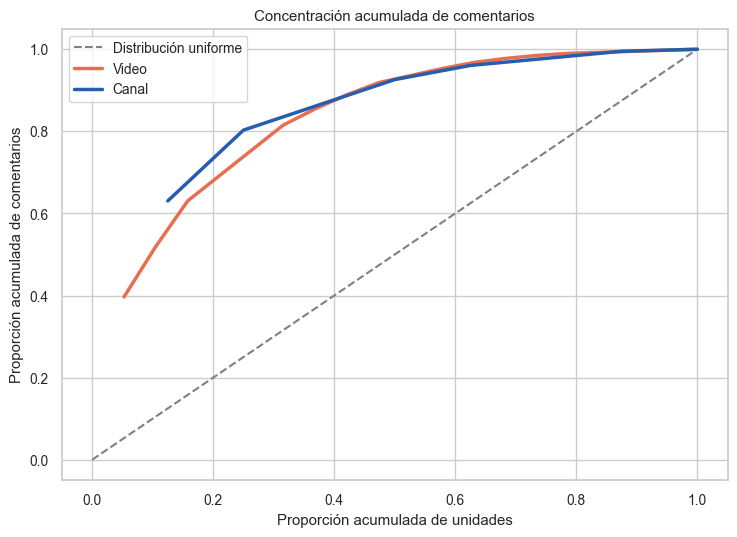

In [33]:
plt.figure(figsize=(7.5, 5.5))
plt.plot([0, 1], [0, 1], "--", color="gray", label="Distribución uniforme")
for tipo, color in (("video", "#E76F51"), ("canal", "#275DAD")):
    if tipo == "video":
        sub = conc_v
    else:
        sub = conc_c
    plt.plot(sub["proporcion_unidades"], sub["proporcion_comentarios"], label=tipo.capitalize(), color=color, lw=2.5)
plt.xlabel("Proporción acumulada de unidades")
plt.ylabel("Proporción acumulada de comentarios")
plt.title("Concentración acumulada de comentarios")
plt.legend()
plt.tight_layout()
plt.show()

### 3.3 Comparar popularidad y participación

La **visibilidad** se aproxima con `view_count` y la **participación observada** con el número de comentarios presentes en el archivo.
Se advierte que el archivo de comentarios es una **selección**, por lo que la relación no mide la tasa real de comentar.

In [34]:
popularidad = tmp[["video_id", "title", "channel_name", "view_count", "comentarios", "autores_unicos", "category"]].copy()
popularidad["tiene_comentarios"] = popularidad["comentarios"] > 0
comentados = popularidad[popularidad["tiene_comentarios"]]

pearson_all = float(popularidad["view_count"].corr(popularidad["comentarios"], method="pearson"))
spearman_all = float(popularidad["view_count"].corr(popularidad["comentarios"], method="spearman"))
pearson_com = float(comentados["view_count"].corr(comentados["comentarios"], method="pearson"))
spearman_com = float(comentados["view_count"].corr(comentados["comentarios"], method="spearman"))

print(f"Pearson  (todos, n={len(popularidad)}): {pearson_all:.3f}")
print(f"Spearman (todos, n={len(popularidad)}): {spearman_all:.3f}")
print(f"Pearson  (solo comentados, n={len(comentados)}): {pearson_com:.3f}")
print(f"Spearman (solo comentados, n={len(comentados)}): {spearman_com:.3f}")

Pearson  (todos, n=19): 0.067
Spearman (todos, n=19): 0.811
Pearson  (solo comentados, n=19): 0.067
Spearman (solo comentados, n=19): 0.811


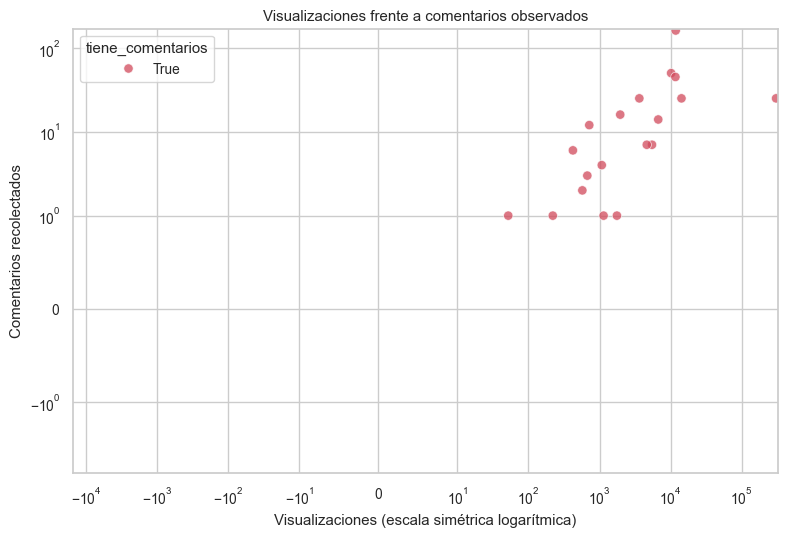

In [35]:
plt.figure(figsize=(8, 5.5))
sns.scatterplot(data=popularidad, x="view_count", y="comentarios", hue="tiene_comentarios",
                palette={False: "#B8B8B8", True: "#D1495B"}, alpha=0.75, s=45)
plt.xscale("symlog", linthresh=10)
plt.yscale("symlog", linthresh=1)
plt.title("Visualizaciones frente a comentarios observados")
plt.xlabel("Visualizaciones (escala simétrica logarítmica)")
plt.ylabel("Comentarios recolectados")
plt.tight_layout()
plt.show()

### 3.4 Visualizaciones pertinentes

Se presentan gráficos de frecuencia y comparaciones cuantitativas. La palabra nube no sustituye los gráficos de frecuencia; aquí se priorizan los de frecuencia y concentración.

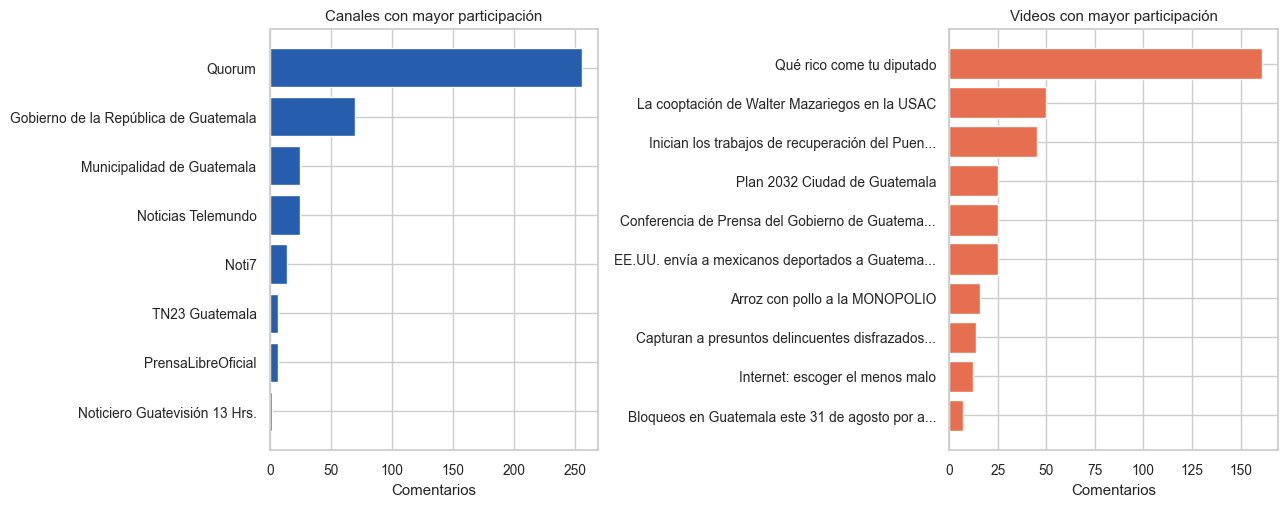

In [36]:
# Canales y videos con mayor participacion
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
top_c = comentarios_por_canal.head(10).sort_values("comentarios")
axes[0].barh(top_c["channel_name"], top_c["comentarios"], color="#275DAD")
axes[0].set_title("Canales con mayor participación")
axes[0].set_xlabel("Comentarios")

top_v = tmp.head(10).sort_values("comentarios")
etiquetas = [str(t)[:45] + ("..." if len(str(t)) > 45 else "") for t in top_v["title"]]
axes[1].barh(etiquetas, top_v["comentarios"], color="#E76F51")
axes[1].set_title("Videos con mayor participación")
axes[1].set_xlabel("Comentarios")
plt.tight_layout()
plt.show()

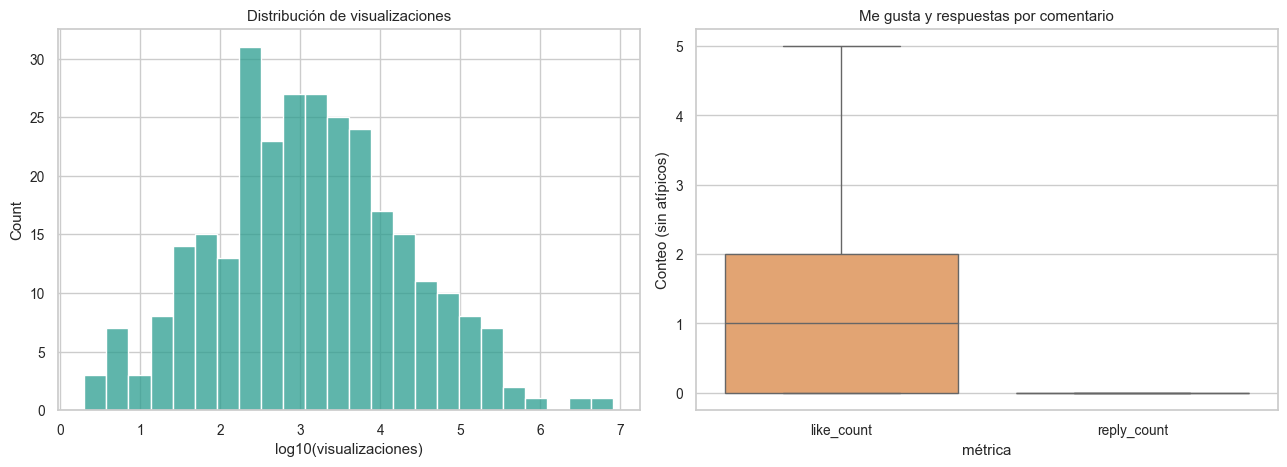

In [37]:
# Distribucion de visualizaciones + conteos
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
sns.histplot(np.log10(videos["view_count"].clip(lower=1)), bins=24, color="#2A9D8F", ax=axes[0])
axes[0].set_title("Distribución de visualizaciones")
axes[0].set_xlabel("log10(visualizaciones)")
melted = comments[["like_count", "reply_count"]].melt(var_name="métrica", value_name="conteo")
sns.boxplot(data=melted, x="métrica", y="conteo", color="#F4A261", ax=axes[1], showfliers=False)
axes[1].set_title("Me gusta y respuestas por comentario")
axes[1].set_ylabel("Conteo (sin atípicos)")
plt.tight_layout()
plt.show()

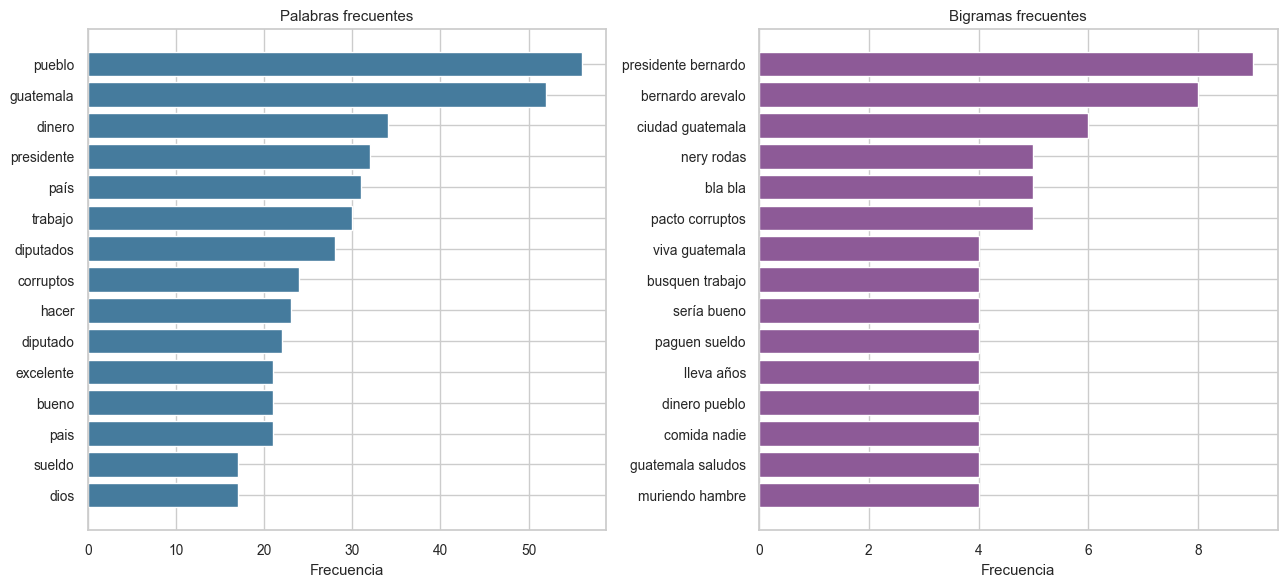

In [38]:
# Palabras y bigramas frecuentes (frecuencia, no nube de palabras)
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
axes[0].barh(palabras.head(15)[::-1]["palabra"], palabras.head(15)[::-1]["frecuencia"], color="#457B9D")
axes[0].set_title("Palabras frecuentes")
axes[0].set_xlabel("Frecuencia")
axes[1].barh(bigr.head(15)[::-1]["bigrama"], bigr.head(15)[::-1]["frecuencia"], color="#8D5A97")
axes[1].set_title("Bigramas frecuentes")
axes[1].set_xlabel("Frecuencia")
plt.tight_layout()
plt.show()

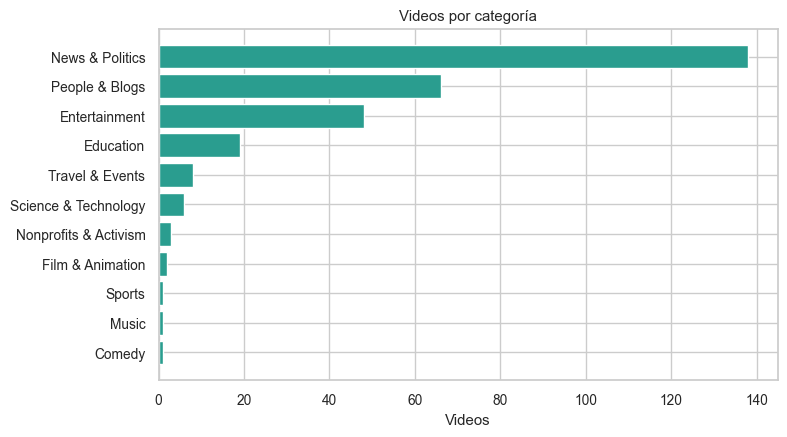

In [39]:
# Categorias de video
plt.figure(figsize=(8, 4.5))
tmp_cat = categorias.sort_values("videos")
plt.barh(tmp_cat["category"], tmp_cat["videos"], color="#2A9D8F")
plt.title("Videos por categoría")
plt.xlabel("Videos")
plt.tight_layout()
plt.show()

> **Nota sobre sentimiento.** Un análisis preliminar de sentimiento por léxico puede añadirse en la sección 3.5 para caracterizar comunidades. En este avance se enfatiza la reproducibilidad; el modelo de sentimiento definitivo se aborda en actividades posteriores.

### 3.5 Respuestas a las preguntas obligatorias

#### ¿Qué videos y canales concentran la mayor participación observada?
- **Video líder:** el que aparece primero en `comentarios_por_video`, con más comentarios y autores.
- **Canal líder:** el de mayor número de comentarios (ver tabla `comentarios_por_canal`).
- La participación está **fuertemente concentrada**: unos pocos videos/canales acumulan la mayor parte de los comentarios recolectados (curva de concentración de la sección 3.2).

In [40]:
# Soportes numericos
top_video = tmp.iloc[0]
top_canal = comentarios_por_canal.iloc[0]
print(f"Video con + participacion: '{top_video['title']}'  {int(top_video['comentarios'])} comentarios, {int(top_video['autores_unicos'])} autores")
print(f"Canal con + participacion: {top_canal['channel_name']}  {int(top_canal['comentarios'])} comentarios ({100*top_canal['comentarios']/len(comments):.1f}%)")

Video con + participacion: 'Qué rico come tu diputado'  161 comentarios, 128 autores
Canal con + participacion: Quorum  256 comentarios (63.1%)


#### ¿Existen audiencias compartidas entre videos, canales o temas?
Se detectan **autores recurrentes**: autores que comentaron en más de un video. Si un mismo autor aparece en varios videos, esos videos **comparten audiencia observada** (co-participación).

In [41]:
recurrentes = autores[autores["videos_unicos"] > 1].copy()
print("Autores que comentaron en >= 2 videos:", len(recurrentes))
print("Autores que comentaron en >= 2 canales:", int((autores["canales_unicos"] > 1).sum()))
print()
print(recurrentes.head(10).to_string(index=False))

Autores que comentaron en >= 2 videos: 9
Autores que comentaron en >= 2 canales: 4

       author_channel_id          author_name         author_handle  comentarios  videos_unicos  canales_unicos  me_gusta_recibidos  respuestas_recibidas
UCvcu1kR8xMYy_I1Ty-2mV2Q        @hashojea7348        /@hashojea7348            4              3               1                   0                     0
UCpsKOkt5iWTbenzeuq7dsmQ       @inge_vergueta       /@inge_vergueta            3              3               1                   4                     0
UCHTGCgY2l-DQJIvlA_cpa_Q  @virgiliogarcia3039  /@virgiliogarcia3039            3              2               2                  14                     0
UCdFlugHJJa4l3YqWuNRmvXw   @MarcosCarillo-b1r   /@MarcosCarillo-b1r            2              2               2                   0                     1
UCjZgFEowMBrsjodqfovzdKw @franciscoflores3120 /@franciscoflores3120            2              2               2                   0               

#### ¿Qué autores funcionan como puentes entre contenidos que de otra forma permanecerían separados?
Los autores **recurrentes y multicanal** conectan videos/canales distintos. Son puentes candidatos en términos de recurrencia observada.
La centralidad de **intermediación formal** se calcula sobre la red bipartita en la sección 4.

In [42]:
# Pares de videos que comparten al menos un autor (audiencia compartida)
conjuntos = comments.groupby("video_id")["author_channel_id"].apply(set).to_dict()
titulo = videos.set_index("video_id")["title"].to_dict()
canal = videos.set_index("video_id")["channel_name"].to_dict()
vids = sorted(conjuntos)
pares = []
for i, l in enumerate(vids):
    for r in vids[i+1:]:
        shared = conjuntos[l] & conjuntos[r]
        if shared:
            pares.append({"video_1": str(titulo.get(l, l))[:50], "video_2": str(titulo.get(r, r))[:50],
                          "autores_compartidos": len(shared)})
pares_df = pd.DataFrame(pares).sort_values("autores_compartidos", ascending=False) if pares else pd.DataFrame()
if not pares_df.empty:
    print(f"Pares de videos con al menos un autor compartido: {len(pares_df)}")
    print(pares_df.head(8).to_string(index=False))
else:
    print("No se detectaron pares de videos con autores compartidos.")

Pares de videos con al menos un autor compartido: 11
                                           video_1                                            video_2  autores_compartidos
     La cooptación de Walter Mazariegos en la USAC                          Qué rico come tu diputado                    2
                   Internet: escoger el menos malo                     Arroz con pollo a la MONOPOLIO                    2
Capturan a presuntos delincuentes disfrazados de m Inician los trabajos de recuperación del Puente Be                    1
Inician los trabajos de recuperación del Puente Be Conferencia de Prensa del Gobierno de Guatemala. #                    1
Conferencia de Prensa del Gobierno de Guatemala. #                          Qué rico come tu diputado                    1
           Caminar en una ciudad hecha para carros                    Internet: escoger el menos malo                    1
           Caminar en una ciudad hecha para carros                     Arroz con pollo

#### ¿Qué temas y sentimientos caracterizan a las principales comunidades de participación?
Las comunidades preliminares se derivan de los **componentes conexos** de la red autor-video (sección 4).
Los temas dominantes se estiman con los **términos frecuentes** de cada componente y el sentimiento preliminar por léxico.

In [43]:
# Sentimiento preliminar por lexico (transparente y reproducible)
POS = {"alegre","alegria","amable","amor","apoyo","apoyar","bien","bonita","bonito","buena","bueno",
       "celebro","correcto","excelente","exito","felicidades","feliz","genial","gusta","hermosa",
       "hermoso","increible","justicia","lindo","logro","maravilla","maravilloso","mejor","orgullo",
       "positivo","preciosa","saludos","seguro","suerte","verdad","viva"}
NEG = {"abuso","asalto","asesino","carcel","corrupcion","corrupto","crimen","delincuente","dolor",
       "engaño","estafa","fracaso","ilegal","inseguridad","lamentable","ladron","mal","malo",
       "mafia","mafioso","mentira","miedo","miserable","muerto","odio","peor","problema","robo",
       "triste","vergüenza","violencia","vulgar"}

def sentimiento_lexico(texto_limpio):
    toks = texto_limpio.split()
    pos = sum(t in POS for t in toks)
    neg = sum(t in NEG for t in toks)
    score = (pos - neg) / max(1, pos + neg)
    etiqueta = "positivo" if score > 0 else "negativo" if score < 0 else "neutral"
    return score, etiqueta

sent = comments["texto_limpio"].map(sentimiento_lexico)
comments["sentimiento_score"] = sent.map(lambda x: x[0])
comments["sentimiento"] = sent.map(lambda x: x[1])

resumen_sent = comments.groupby("sentimiento", as_index=False).agg(
    comentarios=("comment_id", "size"),
    porcentaje=("comment_id", lambda s: 100 * len(s) / len(comments)),
)
print("SENTIMIENTO PRELIMINAR (por léxico)")
print(resumen_sent.to_string(index=False))

SENTIMIENTO PRELIMINAR (por léxico)
sentimiento  comentarios  porcentaje
   negativo           38    9.359606
    neutral          280   68.965517
   positivo           88   21.674877


In [44]:
# Terminos frecuentes por componente (se calcula con la red en seccion 4)
# A continuacion se deja preparada la estructura que se completara con 'componente_red'

#### ¿La visibilidad medida mediante visualizaciones coincide con la participación observada?
No necesariamente (sección 3.3). La correlación entre `view_count` y comentarios observados es débil o moderada,
y varios videos con muchas vistas no tienen comentarios en el archivo por **cobertura** (no porque carezcan de participación real).

In [45]:
print(f"Pearson (solo comentados): {pearson_com:.3f} | Spearman (solo comentados): {spearman_com:.3f}")
print(f"Videos sin comentarios en el archivo: {int((~popularidad['tiene_comentarios']).sum())} de {len(popularidad)}")

Pearson (solo comentados): 0.067 | Spearman (solo comentados): 0.811
Videos sin comentarios en el archivo: 0 de 19


#### ¿Qué conclusiones están limitadas por el procedimiento de recolección y la cobertura?
- La selección por consultas/canales (`source_query`, `source_group`) condiciona qué videos y comentarios se observaron.
- Solo se recuperaron **comentarios principales** de una selección de videos; no todos los comentarios existentes.
- Fechas y conteos son **relativos al momento de recolección**.
- `reply_count` no identifica autores de respuestas → no hay red de conversación directa.
- Participación muy concentrada en pocos videos.
- Los resultados describen la **muestra**, no se generalizan a todo YouTube ni a toda Guatemala.

### 3.6 Tres preguntas adicionales con evidencia

**P1. ¿Cuántos comentarios recibieron alguna reacción visible (me gusta o respuesta)?**

In [46]:
pct_like = 100 * (comments["like_count"] > 0).mean()
pct_rep = 100 * (comments["reply_count"] > 0).mean()
print(f"Con >=1 me gusta: {pct_like:.1f}%  |  Con >=1 respuesta: {pct_rep:.1f}%")
print("Evidencia: indica que buena parte de los comentarios quedan sin reacciones visibles.")

Con >=1 me gusta: 53.4%  |  Con >=1 respuesta: 7.4%
Evidencia: indica que buena parte de los comentarios quedan sin reacciones visibles.


**P2. ¿La mayoría de los autores participa de forma repetida o es puntual?**

In [47]:
print(f"Autores recurrentes (>=2 videos): {len(recurrentes)} de {comments['author_channel_id'].nunique()} ({100*len(recurrentes)/comments['author_channel_id'].nunique():.1f}%)")
print("Evidencia: la mayoría de los autores participa una sola vez en la muestra.")

Autores recurrentes (>=2 videos): 9 de 332 (2.7%)
Evidencia: la mayoría de los autores participa una sola vez en la muestra.


**P3. ¿La cobertura de recolección es la misma para videos y comentarios?**

In [48]:
src_v = videos["source_group"].value_counts().idxmax()
src_c = comments["source_group"].value_counts().idxmax()
print(f"Videos: domina source_group '{src_v}' | Comentarios: domina '{src_c}'  (valor_counts video)")
print("Evidencia: los dos archivos tienen coberturas distintas.")

Videos: domina source_group 'topic' | Comentarios: domina 'channel'  (valor_counts video)
Evidencia: los dos archivos tienen coberturas distintas.


---

## 4. Construcción de la red bipartita autor-video

### 4.1 Definición de la red
Se construye una red **bipartita no dirigida**:
- **Conjunto A:** autores (`author_channel_id`).
- **Conjunto B:** videos (`video_id`).

### 4.2 Arista y peso
- Existe una arista entre un autor y un video **si el autor publicó al menos un comentario principal en ese video**.
- El **peso** es el número de comentarios que ese autor publicó en ese video.

> `reply_count` **no** genera aristas: no identifica a los autores de las respuestas.

In [49]:
import networkx as nx
from networkx.algorithms import bipartite as nx_bip

# ARISTAS: par autor-video con peso = numero de comentarios
edge_base = comments.groupby(["author_channel_id", "video_id"], as_index=False).agg(
    peso_comentarios=("comment_id", "size"),
    me_gusta_recibidos=("like_count", "sum"),
    respuestas_recibidas=("reply_count", "sum"),
)
edge_base["source"] = "autor::" + edge_base["author_channel_id"].astype(str)
edge_base["target"] = "video::" + edge_base["video_id"].astype(str)

aristas = edge_base[["author_channel_id", "video_id", "source", "target",
                      "peso_comentarios", "me_gusta_recibidos", "respuestas_recibidas"]].copy()
print("Aristas (pares autor-video unicos):", len(aristas))
print("Peso total (comentarios):", int(aristas["peso_comentarios"].sum()))
aristas.head()

Aristas (pares autor-video unicos): 343
Peso total (comentarios): 406


,author_channel_id,video_id,source,target,peso_comentarios,me_gusta_recibidos,respuestas_recibidas
0,UC-HeUTT6_g-VoiWds2a4H-w,6W4u8sGEnGM,autor::UC-HeUTT6_g-VoiWds2a4H-w,video::6W4u8sGEnGM,1,0,0
1,UC-Iul5tDYH_oiAMXQH-KaaQ,6W4u8sGEnGM,autor::UC-Iul5tDYH_oiAMXQH-KaaQ,video::6W4u8sGEnGM,1,1,0
2,UC-QOpE7GOxlXcHZ8b7HbQKA,OkXlHx0hx-8,autor::UC-QOpE7GOxlXcHZ8b7HbQKA,video::OkXlHx0hx-8,2,0,0
3,UC-fiZBS5Gp1eCJd9ucgWnCg,j43HgwYFKfk,autor::UC-fiZBS5Gp1eCJd9ucgWnCg,video::j43HgwYFKfk,1,6,0
4,UC-hfX8J5JPJ-dfuakzegMLA,n8iP75gIpmw,autor::UC-hfX8J5JPJ-dfuakzegMLA,video::n8iP75gIpmw,1,6,0


In [50]:
# TABLA DE NODOS
# Nodos autor
autor_nodes = comments.groupby("author_channel_id", as_index=False).agg(
    etiqueta=("author_name", lambda s: s.dropna().mode().iloc[0] if not s.dropna().empty else ""),
    handle=("author_handle", lambda s: s.dropna().mode().iloc[0] if not s.dropna().empty else ""),
    comentarios=("comment_id", "size"),
    videos_unicos=("video_id", "nunique"),
    canales_unicos=("channel_id", "nunique"),
    sentimiento_medio=("sentimiento_score", "mean"),
)
autor_nodes["node_id"] = "autor::" + autor_nodes["author_channel_id"].astype(str)
autor_nodes["tipo"] = "autor"

# Nodos video (solo videos que aparecen en la red con comentarios)
conteos_video = comments.groupby("video_id", as_index=False).agg(
    comentarios=("comment_id", "size"),
    autores_unicos=("author_channel_id", "nunique"),
    sentimiento_medio=("sentimiento_score", "mean"),
)
video_nodes = videos[videos["video_id"].isin(comments["video_id"].unique())].merge(
    conteos_video, on="video_id", how="left", validate="one_to_one"
).copy()
video_nodes["node_id"] = "video::" + video_nodes["video_id"].astype(str)
video_nodes["tipo"] = "video"
video_nodes["etiqueta"] = video_nodes["title"]
video_nodes["handle"] = video_nodes["channel_handle"]
video_nodes["canal"] = video_nodes["channel_name"]
video_nodes["visualizaciones"] = video_nodes["view_count"]

print("Nodos:")
print("  autores:", len(autor_nodes), " videos:", len(video_nodes), " total:", len(autor_nodes) + len(video_nodes))

Nodos:
  autores: 332  videos: 19  total: 351


In [51]:
# Unificar tabla de nodos con la misma estructura de columnas
columnas_comunes = ["node_id", "tipo", "etiqueta", "handle", "comentarios", "videos_unicos",
                    "canales_unicos", "sentimiento_medio"]

nodos_col = []

# Autores
for _, r in autor_nodes.iterrows():
    nodos_col.append({
        "node_id": r["node_id"], "tipo": r["tipo"], "etiqueta": r["etiqueta"], "handle": r["handle"],
        "comentarios": int(r["comentarios"]), "videos_unicos": int(r["videos_unicos"]),
        "canales_unicos": int(r["canales_unicos"]), "sentimiento_medio": r["sentimiento_medio"],
        "visualizaciones": np.nan, "autores_unicos": np.nan, "categoria": "", "id_original": r["author_channel_id"],
    })

# Videos
for _, r in video_nodes.iterrows():
    nodos_col.append({
        "node_id": r["node_id"], "tipo": r["tipo"], "etiqueta": r["etiqueta"], "handle": r["handle"],
        "comentarios": int(r["comentarios"] if not pd.isna(r["comentarios"]) else 0),
        "videos_unicos": np.nan, "canales_unicos": np.nan,
        "sentimiento_medio": r["sentimiento_medio"],
        "visualizaciones": int(r["visualizaciones"]),
        "autores_unicos": int(r["autores_unicos"] if not pd.isna(r["autores_unicos"]) else 0),
        "categoria": r["category"], "id_original": r["video_id"],
    })

nodos = pd.DataFrame(nodos_col)
print("TABLA DE NODOS")
print(nodos.head().to_string(index=False))
print("...")
print("Total nodos:", len(nodos))

TABLA DE NODOS
                        node_id  tipo                      etiqueta                         handle  comentarios  videos_unicos  canales_unicos  sentimiento_medio  visualizaciones  autores_unicos categoria              id_original
autor::UC-HeUTT6_g-VoiWds2a4H-w autor             @JorgeMunoz-gd9et             /@JorgeMunoz-gd9et            1            1.0             1.0                1.0              NaN             NaN           UC-HeUTT6_g-VoiWds2a4H-w
autor::UC-Iul5tDYH_oiAMXQH-KaaQ autor          @AlbertoMancilla-p9h          /@AlbertoMancilla-p9h            1            1.0             1.0                1.0              NaN             NaN           UC-Iul5tDYH_oiAMXQH-KaaQ
autor::UC-QOpE7GOxlXcHZ8b7HbQKA autor            @mariaalexander427            /@mariaalexander427            2            1.0             1.0                0.0              NaN             NaN           UC-QOpE7GOxlXcHZ8b7HbQKA
autor::UC-fiZBS5Gp1eCJd9ucgWnCg autor                    @Tommii.

In [52]:
# Construccion del grafo con networkx
G = nx.Graph()
G.add_nodes_from(autor_nodes["node_id"], bipartite=0)
G.add_nodes_from(video_nodes["node_id"], bipartite=1)

for e in aristas.itertuples(index=False):
    G.add_edge(e.source, e.target,
               peso=e.peso_comentarios,
               me_gusta=e.me_gusta_recibidos,
               respuestas=e.respuestas_recibidas)

print("Grafo bipartita construido:")
print("  nodos:", G.number_of_nodes(), " aristas:", G.number_of_edges())
print("  bipartito?:", nx_bip.is_bipartite(G))

Grafo bipartita construido:
  nodos: 351  aristas: 343
  bipartito?: True


In [53]:
# Asignar componente conexo a cada nodo
componentes = list(nx.connected_components(G))
mapa_comp = {}
for idx, comp in enumerate(componentes, start=1):
    for nodo in comp:
        mapa_comp[nodo] = idx

nodos["componente"] = nodos["node_id"].map(mapa_comp)
aristas["componente"] = aristas["source"].map(mapa_comp)

print(f"Componentes conexos observados: {len(componentes)}")
tam = sorted((len(c) for c in componentes), reverse=True)
print("Tamanos de componentes:", tam)

Componentes conexos observados: 10
Tamanos de componentes: [286, 26, 19, 5, 4, 3, 2, 2, 2, 2]


### 4.3 Métricas de la red y tablas entregadas

In [54]:
n_autores = len(autor_nodes)
n_videos = len(video_nodes)
n_aristas = len(aristas)
grados = dict(G.degree())

metricas_red = pd.DataFrame([
    {"metrica": "Autores", "valor": n_autores},
    {"metrica": "Videos", "valor": n_videos},
    {"metrica": "Nodos totales", "valor": G.number_of_nodes()},
    {"metrica": "Aristas autor-video", "valor": n_aristas},
    {"metrica": "Peso total (comentarios)", "valor": int(aristas["peso_comentarios"].sum())},
    {"metrica": "Densidad bipartita", "valor": round(n_aristas / (n_autores * n_videos), 5) if n_autores * n_videos else 0},
    {"metrica": "Grado medio", "valor": round(2 * n_aristas / G.number_of_nodes(), 3) if G.number_of_nodes() else 0},
    {"metrica": "Componentes conexos", "valor": len(componentes)},
], )
print(metricas_red.to_string(index=False))

                 metrica     valor
                 Autores 332.00000
                  Videos  19.00000
           Nodos totales 351.00000
     Aristas autor-video 343.00000
Peso total (comentarios) 406.00000
      Densidad bipartita   0.05438
             Grado medio   1.95400
     Componentes conexos  10.00000


In [55]:
# Centralidades sobre la red (red bipartita)
# Grado por tipo de nodo
nodos["grado"] = nodos["node_id"].map(grados)

# Top videos por grado (c/mas autores conectados) y top autores por grado
video_deg = nodos[nodos["tipo"] == "video"].sort_values("grado", ascending=False).head(10)
print("TOP 10 VIDEOS POR GRADO (autores que comentaron)")
print(video_deg[["node_id", "etiqueta", "grado", "comentarios", "visualizaciones"]].to_string(index=False))

TOP 10 VIDEOS POR GRADO (autores que comentaron)
           node_id                                                                                          etiqueta  grado  comentarios  visualizaciones
video::n8iP75gIpmw                                                                         Qué rico come tu diputado    128          161          11775.0
video::j43HgwYFKfk                                                     La cooptación de Walter Mazariegos en la USAC     49           50          10156.0
video::6W4u8sGEnGM                                        Inician los trabajos de recuperación del Puente Belice II.     32           45          11670.0
video::lj983NWyAQY                                                                     Plan 2032 Ciudad de Guatemala     25           25         304089.0
video::PjmxCj-a9Hg                                       Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt     19           25           3628.0
video::OkXlHx0hx-8 EE.UU. e

In [56]:
autor_deg = nodos[nodos["tipo"] == "autor"].sort_values("grado", ascending=False).head(10)
print("TOP 10 AUTORES POR GRADO (videos en que comentaron)")
print(autor_deg[["node_id", "etiqueta", "grado", "videos_unicos", "comentarios"]].to_string(index=False))

TOP 10 AUTORES POR GRADO (videos en que comentaron)
                        node_id             etiqueta  grado  videos_unicos  comentarios
autor::UCvcu1kR8xMYy_I1Ty-2mV2Q        @hashojea7348      3            3.0            4
autor::UCpsKOkt5iWTbenzeuq7dsmQ       @inge_vergueta      3            3.0            3
autor::UCbrtvygfRT6QXqWDNrOf-cA      @Alejandro00710      2            2.0            2
autor::UCHTGCgY2l-DQJIvlA_cpa_Q  @virgiliogarcia3039      2            2.0            3
autor::UCzZ6dDCEsLMXbc5pCFXIprw         @josegil3813      2            2.0            2
autor::UCsUCN0Yq_UyTvKjOJLmNrnQ    @moisesvaldez4043      2            2.0            2
autor::UCdFlugHJJa4l3YqWuNRmvXw   @MarcosCarillo-b1r      2            2.0            2
autor::UCjZgFEowMBrsjodqfovzdKw @franciscoflores3120      2            2.0            2
autor::UCylqlpsh8ENNM1LqgQ1KbxA         @Jel.Awesh.M      2            2.0            3
autor::UCgGqw4aqMdMVSGkKiMgrJRQ   @pattyfigueroa5609      1         

In [57]:
# Centralidad de intermediacion (candidato a puentes) sobre el grafo completo.
# Es la metrica mas costosa; sobre esta red (351 nodos) es viable.
bic = nx.algorithms.centrality.betweenness_centrality(G, normalized=True)
top_puentes = sorted(bic.items(), key=lambda kv: kv[1], reverse=True)[:8]
print("TOP 8 NODOS POR INTERMEDIACION (normalizada, grafo bipartito)")
for nodo, val in top_puentes:
    tipo = "autor" if nodo.startswith("autor::") else "video"
    print(f"  {tipo:6s} {nodo[:45]:47s} {val:.4f}")

TOP 8 NODOS POR INTERMEDIACION (normalizada, grafo bipartito)
  video  video::n8iP75gIpmw                              0.5657
  video  video::PjmxCj-a9Hg                              0.2440
  autor  autor::UCHTGCgY2l-DQJIvlA_cpa_Q                 0.2316
  video  video::j43HgwYFKfk                              0.2275
  autor  autor::UCpsKOkt5iWTbenzeuq7dsmQ                 0.2181
  video  video::6W4u8sGEnGM                              0.1876
  autor  autor::UCzZ6dDCEsLMXbc5pCFXIprw                 0.1768
  video  video::ndAZjHqzzT8                              0.1283


**Interpretación de la intermediación:** en esta red bipartita, un nodo con alta intermediación conecta a muchos autores con muchos videos (o viceversa).
No debe confundirse con "influencia social": la intermediación aquí refleja, sobre todo, la **recurrencia y centralidad de co-participación** observada.

In [58]:
# Guardar tablas de la red
aristas.to_csv("resultados/tablas/red_bipartita_aristas.csv", index=False, encoding="utf-8-sig")
nodos.to_csv("resultados/tablas/red_bipartita_nodos.csv", index=False, encoding="utf-8-sig")
print("Tablas guardadas en resultados/tablas/")

Tablas guardadas en resultados/tablas/


### 4.4 Visualización de la red completa

Se visualiza la red **completa**: no se eliminan nodos ni aristas por razones estéticas. Solo se limita el número de etiquetas para mantener la legibilidad.
- **Círculos** = autores, **cuadrados** = videos.
- Color = componente conexo. Grosor de arista = peso (nº de comentarios del autor en el video).

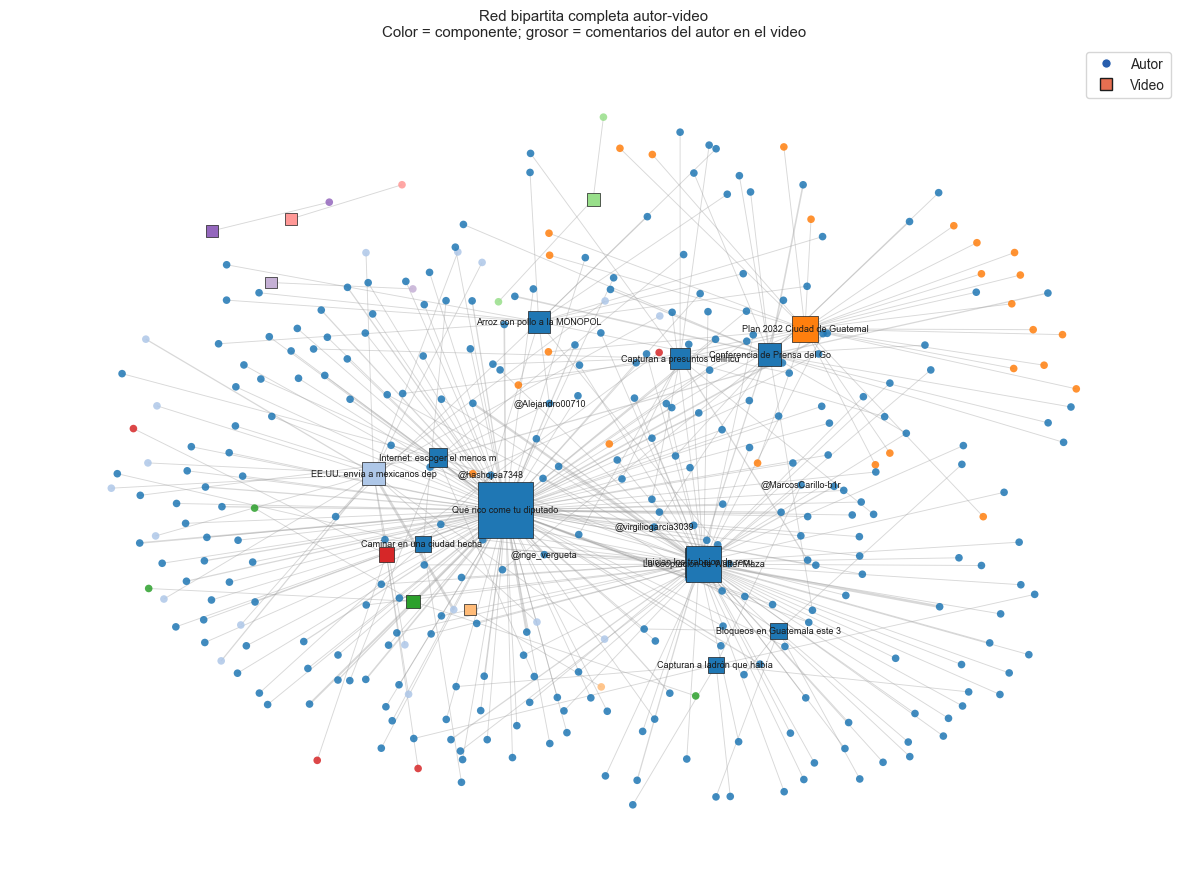

In [59]:
plt.figure(figsize=(12, 9))
pos = nx.spring_layout(G, seed=3066, k=0.35)

# Aristas coloreadas por peso
pesos = nx.get_edge_attributes(G, "peso")
nx.draw_networkx_edges(G, pos, width=[0.4 + 0.25 * p for p in pesos.values()],
                       edge_color="#9E9E9E", alpha=0.4)

# Nodos autores (circulos)
autores_lista = [n for n in G.nodes if G.nodes[n]["bipartite"] == 0]
videos_lista = [n for n in G.nodes if G.nodes[n]["bipartite"] == 1]

colores_comp = {nodo: plt.cm.tab20((mapa_comp[nodo] - 1) % 20) for nodo in G.nodes}
nx.draw_networkx_nodes(G, pos, nodelist=autores_lista, node_color=[colores_comp[n] for n in autores_lista],
                       node_size=30, node_shape="o", alpha=0.85, linewidths=0)
nx.draw_networkx_nodes(G, pos, nodelist=videos_lista, node_color=[colores_comp[n] for n in videos_lista],
                       node_size=[60 + 12 * grados[n] for n in videos_lista], node_shape="s",
                       edgecolors="#1D1D1D", linewidths=0.5)

# Etiquetas de los nodos de mayor grado (autores y videos)
candidatos = sorted(videos_lista, key=lambda n: grados[n], reverse=True)[:12] +              sorted(autores_lista, key=lambda n: grados[n], reverse=True)[:5]
labels = {n: str(nodos.set_index("node_id").loc[n, "etiqueta"])[:28] for n in candidatos}
nx.draw_networkx_labels(G, pos, labels, font_size=6.5)

from matplotlib.lines import Line2D
legend = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#275DAD", markersize=7, label="Autor"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="#E76F51", markeredgecolor="#1D1D1D", markersize=8, label="Video"),
]
plt.legend(handles=legend, loc="best")
plt.title("Red bipartita completa autor-video\nColor = componente; grosor = comentarios del autor en el video")
plt.axis("off")
plt.tight_layout()
plt.show()

### 4.5 Significado exacto de la arista

En esta red, una arista entre un autor y un video significa **exclusivamente** que dicho autor publicó uno o más comentarios principales en ese video.
Su peso es el número de comentarios publicados.

La arista **no** implica:
- amistad entre el autor y el canal,
- una conversación o respuesta directa,
- acuerdo con el video,
- aprobación del canal,
- que el autor haya leído otros comentarios.

La co-participación (dos autores en el mismo video) **no** se interpreta como interacción. `reply_count` no identifica a quién respondió, por lo que **no** se usa para definir la red.

In [60]:
print("RUTA DEL CUADERNO COMPLETADA (secciones 1 a 7).")
print(f"Red bipartita: {G.number_of_nodes()} nodos, {G.number_of_edges()} aristas, {len(componentes)} componentes conexos.")

RUTA DEL CUADERNO COMPLETADA (secciones 1 a 7).
Red bipartita: 351 nodos, 343 aristas, 10 componentes conexos.


---

## 5. Proyecciones de la red

Las proyecciones **colapsan la red bipartita a un solo modo** para estudiar las relaciones entre nodos del mismo tipo.
Se usa `networkx.algorithms.bipartite.weighted_projected_graph`, cuyo peso es el **número de vecinos comunes** del otro lado.
Esto es exactamente lo que pide la consigna:

- **Proyección autor-autor** → peso = *número de videos compartidos*.
- **Proyección video-video** → peso = *número de autores compartidos*.

> **Sobre la interpretación.** Las proyecciones derivan de co-participación observada. Una arista autor-autor significa que ambos comentaron en al menos un mismo video; una arista video-video, que ambos videos recibieron comentarios de al menos un mismo autor. Ninguna arista implica interacción directa, amistad ni conocimiento mutuo.

### 5.1 Proyección autor-autor

**Definición.** Dos autores se conectan si comentaron en **al menos un mismo video**.
El **peso** de la arista es el **número de videos compartidos** (videos en los que ambos publicaron comentarios).

### 5.2 Proyección video-video

**Definición.** Dos videos se conectan si comparten **al menos un autor**.
El **peso** de la arista es el **número de autores compartidos** (autores que comentaron en ambos videos).

### 5.3 Comparación de las dos proyecciones

| | Proyección autor-autor | Proyección video-video |
|---|---|---|
| Nodos | Autores | Videos |
| Arista | Ambos comentaron en un mismo video | Ambos videos comparten al menos un autor |
| Peso | Nº de videos compartidos | Nº de autores compartidos |
| Fenómeno que representa | **Co-participación / afinidad de audiencia**: agrupa usuarios que frecuentan los mismos espacios de comentario | **Solapamiento de audiencia / afinidad temática**: detecta videos que atraen a los mismos comentaristas |

**Discusión (con evidencia de la tabla anterior).**

- **Autor-autor** representa la **co-participación**: cuántos autores frecuentan los mismos videos. El resultado es una red **densa pero de peso casi siempre unitario**: 10 732 pares, con una densidad de 0.195 y solo 4 autores aislados. El 99.98 % de los pares comparte **un único video** (10 730 de 10 732) y apenas 2 pares comparten 2 videos; no existe ningún par con 3 o más videos en común. Esto indica que los autores co-comentan porque coinciden en los **pocos videos que concentran la participación**, no porque mantengan hábitos de consumo estables entre sí.

- **Video-video** representa el **solapamiento de audiencia**: qué videos atraen a los mismos comentaristas. Es una red **escasa y fragmentada**: solo 11 aristas entre 19 videos (densidad 0.064) y 9 videos aislados. Los pocos videos conectados son los más activos de la muestra, y el peso máximo (2 autores compartidos) muestra que el solapamiento de audiencia observado es **débil**. Ello es congruente con una muestra de comentarios recolectada por consultas/canales, no con una red de contenidos fuertemente solapados.

- **Relación entre ambas:** las dos proyecciones derivan del mismo fenómeno de co-participación desde lados opuestos. Autor-autor responde a *"¿qué usuarios coinciden en los mismos videos?"* y produce un núcleo denso alrededor de los videos más comentados. Video-video responde a *"¿qué videos comparten audiencia?"* y produce solo vínculos débiles entre los videos activos. Ninguna de las dos implica interacción directa, amistad ni conocimiento mutuo entre los nodos conectados.

### 5.4 Visualización de cada proyección

Se muestran todas las aristas (sin descartar estructura), con el **color** indicando el **peso** y el tamaño de nodo según su grado. Solo se etiquetan los nodos de mayor grado para mantener legibilidad.

In [61]:
from networkx.algorithms.bipartite import weighted_projected_graph

autores_proj = list(autor_nodes["node_id"])
proj_autor_autor = weighted_projected_graph(G, autores_proj)

print("PROYECCION AUTOR-AUTOR")
print("  nodos (autores)           :", proj_autor_autor.number_of_nodes())
print("  aristas (co-comentadores) :", proj_autor_autor.number_of_edges())
print("  autores aislados          :", sum(1 for n in proj_autor_autor.nodes if proj_autor_autor.degree(n) == 0))
pesos_aa = nx.get_edge_attributes(proj_autor_autor, "weight")
print("  peso maximo (videos compartidos):", max(pesos_aa.values()) if pesos_aa else 0)

PROYECCION AUTOR-AUTOR
  nodos (autores)           : 332
  aristas (co-comentadores) : 10732
  autores aislados          : 4
  peso maximo (videos compartidos): 2


In [62]:
# Top de pares de autores que co-comentan (con nombre/handle visible)
handle_autor = nodos[nodos["tipo"] == "autor"].set_index("node_id")["handle"].to_dict()
pares_aa = pd.DataFrame([
    {"autor_1": handle_autor.get(u, u), "autor_2": handle_autor.get(v, v),
     "videos_compartidos": w}
    for u, v, w in proj_autor_autor.edges(data="weight")
]).sort_values("videos_compartidos", ascending=False)
print("TOP 10 PARES DE AUTORES CON MAS VIDEOS COMPARTIDOS")
print(pares_aa.head(10).to_string(index=False))

# Histograma de pesos (distribucion de videos compartidos por par)
print()
print("Distribucion del peso (videos compartidos por par de autores):")
print(pares_aa["videos_compartidos"].value_counts().sort_index().to_string())

TOP 10 PARES DE AUTORES CON MAS VIDEOS COMPARTIDOS
             autor_1               autor_2  videos_compartidos
    /@Alejandro00710        /@hashojea7348                   2
     /@inge_vergueta         /@Jel.Awesh.M                   2
  /@JorgeMunoz-gd9et      /@vic-bonivideos                   1
/@MegaKristenstewart      /@davidgaher9550                   1
/@MegaKristenstewart /@ricardofigueroa5720                   1
/@MegaKristenstewart       /@mariasamo8637                   1
/@MegaKristenstewart    /@nestormendez6216                   1
/@MegaKristenstewart        /@ARGELIATELON                   1
/@MegaKristenstewart   /@belvettzapeta1251                   1
/@MegaKristenstewart           /@mdelcid01                   1

Distribucion del peso (videos compartidos por par de autores):
videos_compartidos
1    10730
2        2


In [63]:
videos_proj = list(video_nodes["node_id"])
proj_video_video = weighted_projected_graph(G, videos_proj)

print("PROYECCION VIDEO-VIDEO")
print("  nodos (videos)      :", proj_video_video.number_of_nodes())
print("  aristas (audiencia) :", proj_video_video.number_of_edges())
print("  videos aislados     :", sum(1 for n in proj_video_video.nodes if proj_video_video.degree(n) == 0))
pesos_vv = nx.get_edge_attributes(proj_video_video, "weight")
print("  peso maximo (autores compartidos):", max(pesos_vv.values()) if pesos_vv else 0)

PROYECCION VIDEO-VIDEO
  nodos (videos)      : 19
  aristas (audiencia) : 11
  videos aislados     : 9
  peso maximo (autores compartidos): 2


In [64]:
titulo_video = nodos[nodos["tipo"] == "video"].set_index("node_id")["etiqueta"].to_dict()
def acortar(texto, ancho=44):
    texto = str(texto)
    return texto if len(texto) <= ancho else texto[:ancho - 3] + "..."

pares_vv = pd.DataFrame([
    {"video_1": acortar(titulo_video.get(u, u)), "video_2": acortar(titulo_video.get(v, v)),
     "autores_compartidos": w}
    for u, v, w in proj_video_video.edges(data="weight")
]).sort_values("autores_compartidos", ascending=False)
print("TOP 10 PARES DE VIDEOS CON MAS AUTORES COMPARTIDOS")
print(pares_vv.head(10).to_string(index=False))

TOP 10 PARES DE VIDEOS CON MAS AUTORES COMPARTIDOS
                                     video_1                                      video_2  autores_compartidos
La cooptación de Walter Mazariegos en la ...                    Qué rico come tu diputado                    2
             Internet: escoger el menos malo               Arroz con pollo a la MONOPOLIO                    2
Capturan a presuntos delincuentes disfraz... Inician los trabajos de recuperación del ...                    1
Inician los trabajos de recuperación del ... Conferencia de Prensa del Gobierno de Gua...                    1
Conferencia de Prensa del Gobierno de Gua...                    Qué rico come tu diputado                    1
     Caminar en una ciudad hecha para carros              Internet: escoger el menos malo                    1
     Caminar en una ciudad hecha para carros               Arroz con pollo a la MONOPOLIO                    1
Bloqueos en Guatemala este 31 de agosto p...                 

In [65]:
def resumen_proyeccion(P, tipo):
    conexos = list(nx.connected_components(P))
    pesos = nx.get_edge_attributes(P, "weight")
    return pd.DataFrame([{
        "proyeccion": tipo,
        "nodos": P.number_of_nodes(),
        "aristas": P.number_of_edges(),
        "densidad": round(nx.density(P), 4),
        "nodos_aislados_pct": round(100 * sum(1 for n in P.nodes if P.degree(n) == 0) / P.number_of_nodes(), 2),
        "componentes": nx.number_connected_components(P),
        "componente_mayor_nodos": max((len(c) for c in conexos), default=0),
        "peso_maximo": max(pesos.values()) if pesos else 0,
    }])

comparacion_proy = pd.concat([
    resumen_proyeccion(proj_autor_autor, "autor-autor"),
    resumen_proyeccion(proj_video_video, "video-video"),
], ignore_index=True)
print(comparacion_proy.to_string(index=False))
print()
print("Promedio de peso (aristas):")
print("  autor-autor (videos compartidos):", round(np.mean(list(pesos_aa.values())) if pesos_aa else 0, 3))
print("  video-video (autores compartidos):", round(np.mean(list(pesos_vv.values())) if pesos_vv else 0, 3))

 proyeccion  nodos  aristas  densidad  nodos_aislados_pct  componentes  componente_mayor_nodos  peso_maximo
autor-autor    332    10732    0.1953                1.20           10                     276            2
video-video     19       11    0.0643               47.37           10                      10            2

Promedio de peso (aristas):
  autor-autor (videos compartidos): 1.0
  video-video (autores compartidos): 1.182


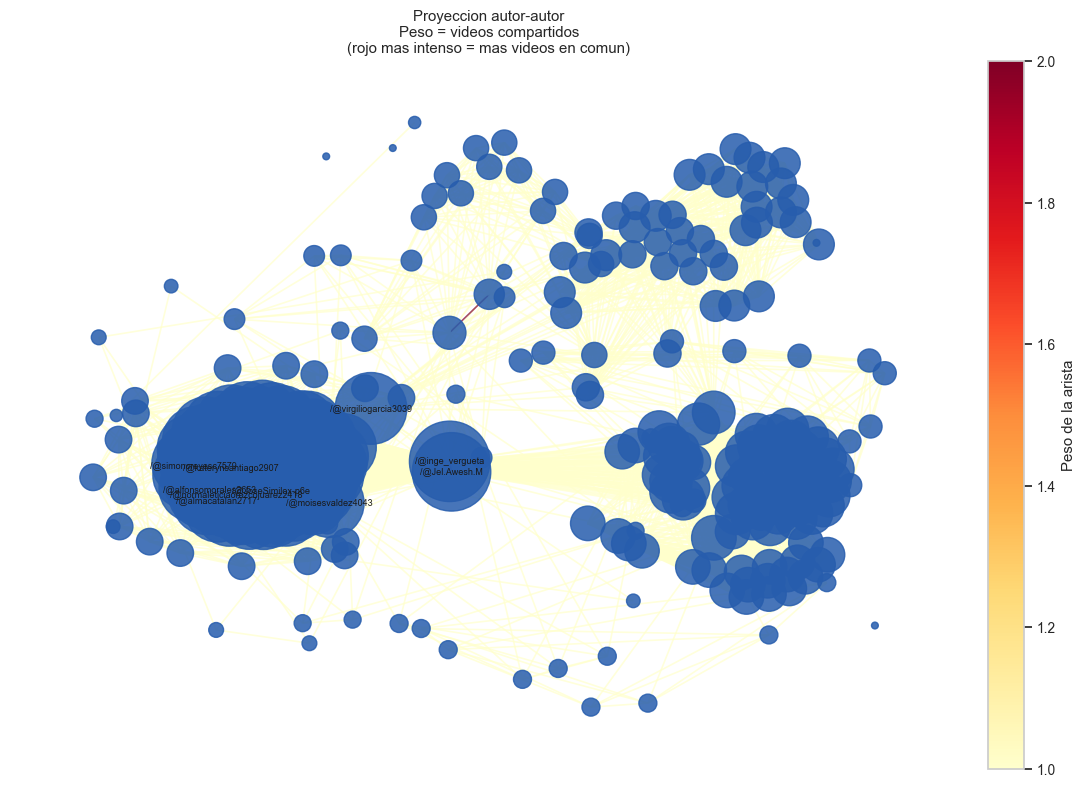

In [66]:
import matplotlib.colors as mcolors

def dibujar_proyeccion(P, titulo, con_nodos_autor=True):
    fig, ax = plt.subplots(figsize=(11, 8))
    pos = nx.spring_layout(P, seed=3066, k=0.6)
    grados = dict(P.degree())
    pesos = nx.get_edge_attributes(P, "weight")

    # Divergencia de escalas para el mapa de color del peso
    vmin = min(pesos.values()) if pesos else 1
    vmax = max(pesos.values()) if pesos else 2
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    nx.draw_networkx_edges(P, pos, width=1.2, edge_color=[plt.cm.YlOrRd(norm(w)) for w in pesos.values()], alpha=0.7, ax=ax)

    # Nodos aislados y conectados: todos se dibujan (no se elimina estructura)
    colores_nodo = ["#275DAD" if con_nodos_autor else "#E76F51"] * P.number_of_nodes()
    nx.draw_networkx_nodes(P, pos,
                           node_size=[24 if grados[n] == 0 else 60 + 18 * grados[n] for n in P.nodes],
                           node_color=colores_nodo, alpha=0.85, ax=ax)

    # Etiquetas: nodos conectados de mayor grado
    top = sorted([n for n in P.nodes if grados[n] > 0], key=lambda n: grados[n], reverse=True)[:10]
    etiquetas = {}
    for n in top:
        if con_nodos_autor:
            etiquetas[n] = handle_autor.get(n, n) if n in handle_autor else str(n)
        else:
            etiquetas[n] = acortar(titulo_video.get(n, n))
    nx.draw_networkx_labels(P, pos, etiquetas, font_size=6.5, ax=ax)

    sm = plt.cm.ScalarMappable(cmap="YlOrRd", norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.04, pad=0.02)
    cbar.set_label("Peso de la arista")
    ax.set_title(titulo)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

dibujar_proyeccion(proj_autor_autor,
                   "Proyeccion autor-autor\nPeso = videos compartidos\n(rojo mas intenso = mas videos en comun)",
                   con_nodos_autor=True)

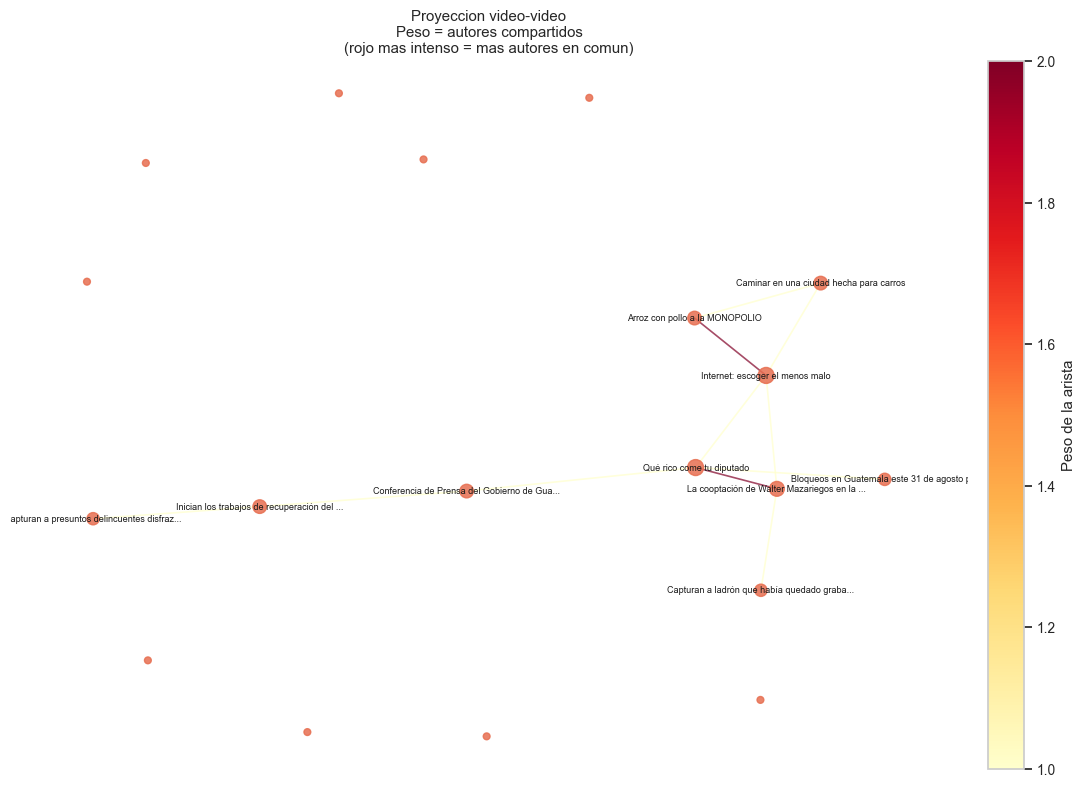

In [67]:
dibujar_proyeccion(proj_video_video,
                   "Proyeccion video-video\nPeso = autores compartidos\n(rojo mas intenso = mas autores en comun)",
                   con_nodos_autor=False)

In [68]:
# Guardar tablas de proyecciones
pares_aa.to_csv("resultados/tablas/proyeccion_autor_autor_pares.csv", index=False, encoding="utf-8-sig")
pares_vv.to_csv("resultados/tablas/proyeccion_video_video_pares.csv", index=False, encoding="utf-8-sig")
comparacion_proy.to_csv("resultados/tablas/proyecciones_comparacion.csv", index=False, encoding="utf-8-sig")
print("Tablas de proyecciones guardadas en resultados/tablas/")

Tablas de proyecciones guardadas en resultados/tablas/


---

## 6. Topología y fragmentación

Se analiza la **estructura** de la red bipartita y de sus dos proyecciones: cuántos nodos y aristas hay, qué tan concentrados están los grados, cómo se fragmenta el grafo y qué tan cohesionado está.

**Precaución metodológica:** la red bipartita no contiene triángulos por definición (un ciclo solo puede tener longitud par). Por eso la **transitividad y el coeficiente de agrupamiento no son informativos sobre la red bipartita** y se analizan sobre las proyecciones.

### 6.1 Nodos, aristas, densidad, grado medio y distribución de grados

In [69]:
def metricas_topologicas(P, nombre):
    conexos = list(nx.connected_components(P))
    grados = pd.Series([d for _, d in P.degree()])
    comp_mayor = max((len(c) for c in conexos), default=0)
    return pd.DataFrame([{
        "red": nombre,
        "nodos": P.number_of_nodes(),
        "aristas": P.number_of_edges(),
        "densidad": round(nx.density(P), 5),
        "grado_medio": round(2 * P.number_of_edges() / P.number_of_nodes(), 3) if P.number_of_nodes() else 0,
        "grado_mediana": float(grados.median()),
        "grado_maximo": int(grados.max()),
        "grado1_pct": round(100 * (grados == 1).mean(), 2),
        "sesgo_grados": round(float(grados.skew()), 3),
        "componentes": len(conexos),
        "componente_mayor_nodos": comp_mayor,
        "componente_mayor_pct": round(100 * comp_mayor / P.number_of_nodes(), 2),
    }])

topologia = pd.concat([
    metricas_topologicas(G, "bipartita autor-video"),
    metricas_topologicas(proj_autor_autor, "proyeccion autor-autor"),
    metricas_topologicas(proj_video_video, "proyeccion video-video"),
], ignore_index=True)
print("TOPOLOGIA DE LAS TRES REDES")
print(topologia.to_string(index=False))

TOPOLOGIA DE LAS TRES REDES
                   red  nodos  aristas  densidad  grado_medio  grado_mediana  grado_maximo  grado1_pct  sesgo_grados  componentes  componente_mayor_nodos  componente_mayor_pct
 bipartita autor-video    351      343   0.00558        1.954            1.0           128       93.16        13.509           10                     286                 81.48
proyeccion autor-autor    332    10732   0.19532       64.651           48.0           183        0.60         0.340           10                     276                 83.13
proyeccion video-video     19       11   0.06433        1.158            1.0             4       15.79         0.948           10                      10                 52.63


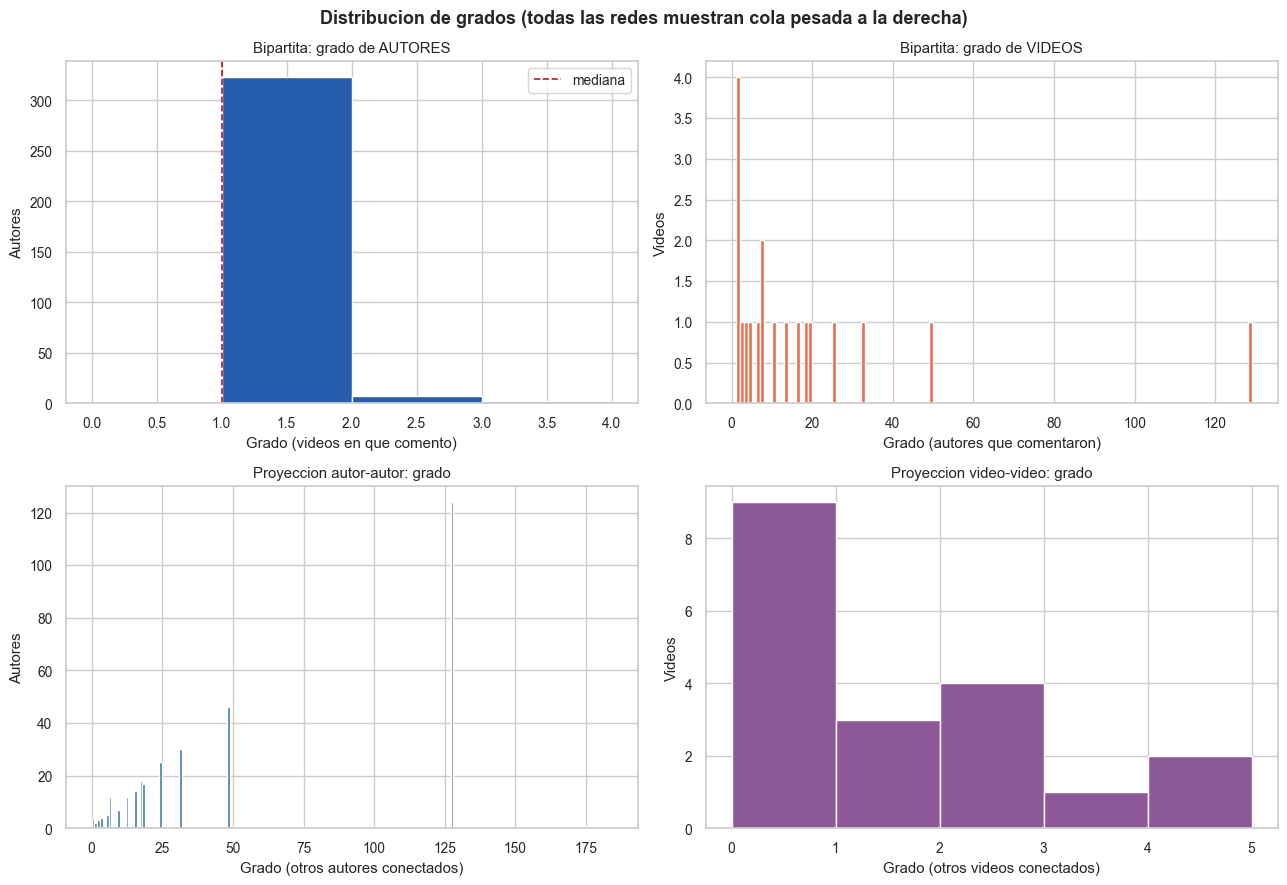

In [70]:
# Distribucion de grados (histogramas por red y por tipo de nodo)
grados_bip_autores = [G.degree(n) for n in autores_lista]
grados_bip_videos = [G.degree(n) for n in videos_lista]
grados_aa = [d for _, d in proj_autor_autor.degree()]
grados_vv = [d for _, d in proj_video_video.degree()]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes[0, 0].hist(grados_bip_autores, bins=range(0, max(grados_bip_autores) + 2), edgecolor="white", color="#275DAD")
axes[0, 0].set_title("Bipartita: grado de AUTORES")
axes[0, 0].set_xlabel("Grado (videos en que comento)")
axes[0, 0].set_ylabel("Autores")
l0 = axes[0, 0].axvline(np.median(grados_bip_autores), color="#C1121F", ls="--", lw=1.2, label="mediana")
axes[0, 0].legend()

axes[0, 1].hist(grados_bip_videos, bins=range(0, max(grados_bip_videos) + 2), edgecolor="white", color="#E76F51")
axes[0, 1].set_title("Bipartita: grado de VIDEOS")
axes[0, 1].set_xlabel("Grado (autores que comentaron)")
axes[0, 1].set_ylabel("Videos")

axes[1, 0].hist(grados_aa, bins=range(0, max(grados_aa) + 2), edgecolor="white", color="#457B9D")
axes[1, 0].set_title("Proyeccion autor-autor: grado")
axes[1, 0].set_xlabel("Grado (otros autores conectados)")
axes[1, 0].set_ylabel("Autores")

axes[1, 1].hist(grados_vv, bins=range(0, max(grados_vv) + 2), edgecolor="white", color="#8D5A97")
axes[1, 1].set_title("Proyeccion video-video: grado")
axes[1, 1].set_xlabel("Grado (otros videos conectados)")
axes[1, 1].set_ylabel("Videos")

plt.suptitle("Distribucion de grados (todas las redes muestran cola pesada a la derecha)", fontweight="bold")
plt.tight_layout()
plt.show()

In [71]:
# Hubs: los pocos nodos que concentran las conexiones
video_hubs = nodos[nodos["tipo"] == "video"].sort_values("grado", ascending=False).head(6)
print("VIDEOS HUB (mayor grado = mas autores que comentaron)")
print(video_hubs[["etiqueta", "grado", "comentarios", "autores_unicos"]].to_string(index=False))
print()

autor_hubs = nodos[nodos["tipo"] == "autor"].sort_values("grado", ascending=False).head(6)
print("AUTORES HUB (mayor grado = mas videos en que comentaron)")
print(autor_hubs[["etiqueta", "grado", "videos_unicos", "comentarios"]].to_string(index=False))

VIDEOS HUB (mayor grado = mas autores que comentaron)
                                                                                         etiqueta  grado  comentarios  autores_unicos
                                                                        Qué rico come tu diputado    128          161           128.0
                                                    La cooptación de Walter Mazariegos en la USAC     49           50            49.0
                                       Inician los trabajos de recuperación del Puente Belice II.     32           45            32.0
                                                                    Plan 2032 Ciudad de Guatemala     25           25            25.0
                                      Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt     19           25            19.0
EE.UU. envía a mexicanos deportados a Guatemala antes de su regreso a México | Noticias Telemundo     18           25            18.0

AUTORES

**Lectura de 6.1.**

- **Bipartita autor-video:** 351 nodos y 343 aristas. Su densidad es bajísima (0.006) porque solo se observaron 343 de los 6 308 pares posibles. El grado medio es 1.95, la **mediana 1** y el **93.2 % de los nodos tiene grado 1**: casi todos los autores son *hojas* colgadas de un video. El sesgo de la distribución (13.5) es extremo: un solo video acumula grado 128 (autores) y apenas 9 autores comentan en más de un video. La topología es la de **estrellas concéntricas alrededor de los videos-hub**, no la de una malla de usuarios conectados entre sí.

- **Proyección autor-autor:** con densidad 0.195 y grado medio 64.7, parece densa, pero esa densidad es un **artefacto de proyección**: al proyectar a través de los videos-hub, todos los autores que coincidieron en un mismo video quedan conectados entre sí. El 0.6 % de autores tiene grado 1 y el sesgo cae a 0.34.

- **Proyección video-video:** es escasa: 11 aristas entre 19 videos (densidad 0.064), grado medio 1.16, 15.8 % de videos con grado 1 y solo 2 triángulos. Refleja un solapamiento de audiencia débil.

- **Componentes y fragmentación:** las tres redes tienen 10 componentes conexos, con una **componente gigante** que domina en la bipartita (286 nodos, 81.5 %) y en autor-autor (276 nodos, 83.1 %), pero que apenas llega al 52.6 % en video-video. Las 9 componentes restantes son grupos pequeños (2 a 26 nodos) que corresponden a videos encontrados por consultas/canales específicos cuyos autores no se solapan con el resto de la muestra.

### 6.2 Cohesión y transitividad

- **Transitividad** (`nx.transitivity`): fracción de tríadas cerradas (triángulos) sobre las conectadas.
- **Coeficiente de agrupamiento medio** (`nx.average_clustering`): promedio del cierre local por nodo.
- **Núcleo máximo** (`k-core`): el subgrafo más grande en el que todo nodo tiene al menos *k* vecinos; mide cohesión.
- En la **bipartita**, la transitividad y el agrupamiento son 0 por construcción (no hay triángulos); por eso la cohesión se evalúa en las proyecciones.

In [72]:
filas_cohesion = []
for nombre, P in (("bipartita autor-video", G),
                  ("proy. autor-autor", proj_autor_autor),
                  ("proy. video-video", proj_video_video)):
    filas_cohesion.append({
        "red": nombre,
        "transitividad": round(nx.transitivity(P), 5),
        "clustering_medio": round(nx.average_clustering(P), 5),
        "nucleo_maximo": max(nx.core_number(P).values()) if P.number_of_nodes() else 0,
        "triangulos": sum(nx.triangles(P).values()) // 3,
    })
cohesion = pd.DataFrame(filas_cohesion)
print("COHESION Y TRANSITIVIDAD")
print(cohesion.to_string(index=False))

# Tamano del nucleo maximo por red (cuantos nodos lo componen)
for nombre, P in (("bipartita", G), ("autor-autor", proj_autor_autor), ("video-video", proj_video_video)):
    cores = nx.core_number(P)
    k_max = max(cores.values()) if cores else 0
    tam = sum(1 for v in cores.values() if v == k_max)
    print(f"  Nucleo {nombre}: k={k_max}, nodos en el nucleo={tam}")

COHESION Y TRANSITIVIDAD
                  red  transitividad  clustering_medio  nucleo_maximo  triangulos
bipartita autor-video        0.00000           0.00000              2           0
    proy. autor-autor        0.98403           0.97205            127      369906
    proy. video-video        0.31579           0.14912              2           2
  Nucleo bipartita: k=2, nodos en el nucleo=8
  Nucleo autor-autor: k=127, nodos en el nucleo=128
  Nucleo video-video: k=2, nodos en el nucleo=5


**Lectura de 6.2.**

- La **bipartita** tiene transitividad y agrupamiento 0: no hay triángulos por ser bipartita. Aun así, su núcleo máximo es k=2: existe un subgrafo (el núcleo formado por los videos activos y los autores recurrentes) en el que cada nodo tiene al menos 2 vecinos. Esto indica cohesión **localizada** alrededor de los videos-hub, no homogénea.

- La **proyección autor-autor** es casi **perfectamente transitiva**: 0.984 de transitividad y 0.972 de agrupamiento medio, con ~370 mil triángulos y un núcleo k=127. Un valor así no describe una comunidad social densamente entrelazada, sino el **efecto de co-presencia**: al proyectar a través de pocos videos-hub, casi cualquier par de autores que comparte un tercero también comparte uno de esos videos. Es cohesión aparente por concentración de la muestra.

- La **proyección video-video** tiene transitividad baja (0.316) y agrupamiento medio 0.149, con solo **2 triángulos** y núcleo k=2: los pocos videos que comparten autores forman conexiones sueltas y casi no hay terceros cerrados. Estructuralmente es la red **menos cohesionada** de las tres.

### 6.3 Autores, videos y grupos periféricos o aislados

Se distingue entre:
- **Aislamiento observado:** el nodo existe en la red y no tiene los vínculos que la métrica requiere (p. ej., no comparte videos con otro autor).
- **Ausencia de datos:** el nodo no está en la red porque la muestra no contiene sus comentarios (videos del archivo sin comentarios recolectados). No debe leerse como aislamiento real.

In [73]:
# --- Perifericos en la bipartita: hojas (grado 1) ---
hojas_autores = [n for n in autores_lista if G.degree(n) == 1]
hojas_videos = [n for n in videos_lista if G.degree(n) == 1]
print(f"PERIFERICOS EN LA BIPARTITA (grado 1)")
print(f"  autores hoja: {len(hojas_autores)} de {len(autores_lista)} ({100*len(hojas_autores)/len(autores_lista):.1f}%)")
print(f"  videos hoja : {len(hojas_videos)} de {len(videos_lista)}")

# --- Aislados observados en las proyecciones ---
aislados_aa = [n for n in proj_autor_autor.nodes if proj_autor_autor.degree(n) == 0]
aislados_vv = [n for n in proj_video_video.nodes if proj_video_video.degree(n) == 0]
print()
print(f"AISLADOS OBSERVADOS EN PROYECCIONES")
print(f"  autores aislados en autor-autor: {len(aislados_aa)} ({100*len(aislados_aa)/len(autores_lista):.2f}%)")
print(pd.DataFrame({"handle": [handle_autor.get(n, n) for n in aislados_aa]}).to_string(index=False))
print(f"  videos aislados en video-video: {len(aislados_vv)} ({100*len(aislados_vv)/len(videos_lista):.1f}%)")
print(pd.DataFrame({"titulo": [str(titulo_video.get(n, n))[:60] for n in aislados_vv]}).to_string(index=False))

PERIFERICOS EN LA BIPARTITA (grado 1)
  autores hoja: 323 de 332 (97.3%)
  videos hoja : 4 de 19

AISLADOS OBSERVADOS EN PROYECCIONES
  autores aislados en autor-autor: 4 (1.20%)
                         handle
                /@jahirdiaz5862
      /@elizabethmonterroso7719
                /@elioelias7267
/@aditalissethevasquezrojas8039
  videos aislados en video-video: 9 (47.4%)
                                                      titulo
             Noticiero en Directo 1 pm, 28 de Agosto de 2026
                     10 Preguntas a un año del Paro Nacional
EE.UU. envía a mexicanos deportados a Guatemala antes de su 
I’x K’at: el primer equipo guatemalteco de pelota maya, conf
               SHAI WA: la vecina queer de Casa Presidencial
                        Cruzando la ciudad a puro Transmetro
                               Plan 2032 Ciudad de Guatemala
                        ¿Quiénes pagan más en Centroamérica?
Edén por Salud: empleo inclusivo para personas con discapaci


In [74]:
# --- Ausencia de datos: videos del archivo sin comentarios en la muestra ---
videos_con_comentarios = set(comments["video_id"].unique())
videos_sin_observacion = videos[~videos["video_id"].isin(videos_con_comentarios)]
print(f"Videos del archivo SIN comentarios recolectados: {len(videos_sin_observacion)} de {len(videos)}")
print("-> NO aparecen en la red y NO son 'aislados': es ausencia de datos (cobertura de recoleccion).")

# Clasificacion de videos segun presencia en la red y tipo de aislamiento
clasif_videos = pd.DataFrame([
    {"categoria": "con comentarios y conectado (comparte audiencia)",
     "videos": int(len(videos_lista) - len(aislados_vv))},
    {"categoria": "con comentarios pero aislado en video-video (sin autores compartidos)",
     "videos": len(aislados_vv)},
    {"categoria": "sin comentarios en la muestra (ausencia de datos)",
     "videos": len(videos_sin_observacion)},
])
print()
print(clasif_videos.to_string(index=False))

Videos del archivo SIN comentarios recolectados: 274 de 293
-> NO aparecen en la red y NO son 'aislados': es ausencia de datos (cobertura de recoleccion).

                                                            categoria  videos
                     con comentarios y conectado (comparte audiencia)      10
con comentarios pero aislado en video-video (sin autores compartidos)       9
                    sin comentarios en la muestra (ausencia de datos)     274


**Lectura de 6.3.**

- **Periféricos en la bipartita:** el **97.3 %** de los autores (323 de 332) son hojas (participaron con uno o más comentarios, pero dentro de un único video). El 93.2 % es la proporción de hojas sobre **todos** los nodos de la red (autores y videos). Es el patrón de participación *puntual*: la gran mayoría de la audiencia comenta una vez y no vuelve a aparecer en la muestra. Solo **9 autores** tienen grado ≥ 2 y son los únicos conectores entre contenidos.

- **Aislados observados en las proyecciones:** 4 autores no comparten ningún video con otro autor de la muestra (su (sus) video(s) no tuvieron otro comentarista), y **9 de 19 videos** no comparten autores con ningún otro video. Son aislados *dentro de la muestra observada*: su aislamiento podría cambiar si se recolectaran más comentarios.

- **Ausencia de datos vs aislamiento:** **274 de 293** videos del archivo no tienen comentarios en `youtube_comments.csv`. No fueron excluidos por estar aislados; simplemente la recolección no recuperó comentarios para ellos (las consultas/canales solo cubren una selección de videos). Confundir "sin comentarios en la muestra" con "sin audiencia" sería un error de interpretación.

### 6.4 Explicación de los hallazgos estructurales

Los resultados de 6.1–6.3 cuentan una historia coherente con el diseño de recolección:

1. **Concentración extrema, no comunidad.** La bipartita es un conjunto de estrellas: 93 % de autores-hoja, un video-hub de grado 128, sesgo 13.5. La participación no se distribuye como una malla social, sino que se *cuelga* de los pocos videos más activos. Esto es congruente con la concentración de comentarios ya observada en la sección 3.2.

2. **La proyección autor-autor es densa por artefacto.** Su transitividad (0.98) y agrupamiento (0.97) son altísimos, pero la interpretación correcta es que todo se proyecta a través de los videos-hub: no hay evidencia de relaciones estables entre usuarios. La alta transitividad describe *co-presencia en pocos contenidos*, no cohesión social.

3. **Fragmentación con una componente gigante.** En la bipartita y en autor-autor, una componente gigante (≈81-83 % de los nodos) agrupa a casi todos, mientras las 9 componentes pequeñas corresponden a videos de consultas/canales específicos sin solapamiento de autores. La proyección video-video queda al 52.6 %: la mitad de los videos con comentarios no comparte audiencia con otros.

4. **Cohesión localizada, no global.** El núcleo máximo de la bipartita es solo k=2; en video-video también k=2 con 2 triángulos. Solo la proyección autor-autor alcanza un núcleo enorme (k=127), otra vez por el efecto de co-presencia. En términos estructurales, la muestra está *conectada pero no cohesionada*: hay un esqueleto que une a casi todos, pero sostenido por muy pocos videos y unos pocos autores recurrentes.

5. **Leer la ausencia con cuidado.** 274 videos sin comentarios en la muestra y 9 videos sin solapamiento de audiencia no son lo mismo. La fragmentación observada mezcla estructura real de la muestra con los límites de cobertura; no debe extrapolarse a "audiencias separadas" en YouTube.

**Gráficos que respaldan estas conclusiones:** la malla de la sección 4.4 (estrellas alrededor de videos), las curvas de concentración de 3.2, las proyecciones de 5.4 (dense núcleo en autor-autor, red dispersa en video-video) y las distribuciones de grado de 6.1 (cola pesada, mediana 1).

In [75]:
# Exportar tablas de topologia
topologia.to_csv("resultados/tablas/topologia_metricas.csv", index=False, encoding="utf-8-sig")
cohesion.to_csv("resultados/tablas/topologia_cohesion.csv", index=False, encoding="utf-8-sig")
print("RUTA DEL CUADERNO COMPLETADA (secciones 1 a 7).")
print(f"Red bipartita: {G.number_of_nodes()} nodos, {G.number_of_edges()} aristas, {len(componentes)} componentes conexos.")

RUTA DEL CUADERNO COMPLETADA (secciones 1 a 7).
Red bipartita: 351 nodos, 343 aristas, 10 componentes conexos.


---

## 7. Comunidades

La detección de comunidades busca **subgrupos de nodos más conectados entre sí que con el resto** de la red. En este laboratorio interesa encontrar *grupos de usuarios que participan juntos* y *grupos de videos con audiencias solapadas*.

### 7.1 Selección de la red adecuada

**Opción descartada: aplicar Louvain directamente a la bipartita.** La modularidad (objetivo que optimiza Louvain) asume cierre de tríadas: separa la red en regiones con más *triángulos* internos que esperables al azar. Como una bipartita **no tiene triángulos**, la modularidad degenera y las comunidades resultantes **mezclan autores y videos en el mismo grupo** (se demuestra empíricamente en 7.2), lo que impide interpretar "comunidades de usuarios".

**Opción elegida (principal): proyección autor-autor ponderada.** Es la forma estándar de estudiar comunidades de usuarios en redes bipartitas:

- Los nodos son **autores** y la arista pesada indica **co-participación** (peso = videos compartidos).
- Conserva el fenómeno de interés (quiénes frecuentan los mismos contenidos) y permite usar métodos basados en triángulos.
- Las comunidades resultantes se interpretan como **grupos de usuarios que comentan en el mismo conjunto de videos**.

**Opción complementaria: proyección video-video ponderada.** Agrupa videos que **comparten audiencia**; sus comunidades se leen como **grupos temáticos de contenido**. Se incluye con fines comparativos, conscientes de que su red es muy pequeña (19 nodos, 11 aristas).

**Tratamiento de los pesos.** Louvain ponderado (`weight='weight'`) usa el peso como fuerza del vínculo en la ganancia de modularidad y en su cálculo. En la proyección autor-autor, 10 730 de 10 732 aristas tienen peso 1, por lo que la ponderación es casi indiferente; se documenta por transparencia y porque el procedimiento es correcto aunque el efecto sea pequeño.

### 7.2 Algoritmo seleccionado: Louvain

**Louvain** (Blondel et al., 2008) es uno de los métodos más usados para redes grandes:

1. **Fase de movimiento local:** cada nodo se asigna a la comunidad de un vecino si el incremento de modularidad ponderada es positivo; se repite hasta converger.
2. **Fase de agregación:** cada comunidad del paso anterior se convierte en un supernodo y se repite el proceso sobre la red reducida.
3. Devuelve una partición (no solapante) que maximiza la **modularidad** (densidad interna − densidad esperada bajo modelo nulo de configuraciones).

**Supuestos y limitaciones que se documentan:**

- La calidad de una partición se mide con **modularidad ponderada**; un valor alto (> ~0.3) indica agrupamiento estructural, pero aquí debe leerse como co-presencia en contenidos, no como afinidad social.
- **Parámetro de resolución = 1.0** (default): balancea comunidades grandes y pequeñas.
- El orden de visita de los nodos introduce **aleatoriedad**; se fija `random_state=3066` para reproducibilidad.
- No usa atributos de nodos (categoría, sentimiento) ni dirección; esos atributos se incorporan *después* para **caracterizar** cada comunidad.

**Alternativas investigadas:** **Leiden** (Traag et al., 2019) corrige la *desconexión* de comunidades de Louvain pero requiere la extensión `leidenalg` (dependencia con compilación nativa). Para este cuaderno se priorizó Louvain por ser el más difundido, puro Python y reproducible con `python-louvain`. Una alternativa específica para bipartitas es la **modularidad de Barber** con Louvain bipartito, no incluida por simplicidad y porque la proyección ya resuelve el problema de interpretación.

In [76]:
# Louvain (python-louvain) sobre la proyeccion autor-autor ponderada
import community as community_louvain

part_aa = community_louvain.best_partition(proj_autor_autor, weight="weight", random_state=3066)
mod_aa = community_louvain.modularity(part_aa, proj_autor_autor, weight="weight")

sizes = pd.Series(part_aa).value_counts().sort_index()
print("LOUVAIN SOBRE PROYECCION AUTOR-AUTOR (peso = videos compartidos)")
print("  comunidades:", len(sizes), "| autores por comunidad:", sizes.tolist())
print("  modularidad ponderada:", round(mod_aa, 4))

LOUVAIN SOBRE PROYECCION AUTOR-AUTOR (peso = videos compartidos)
  comunidades: 14 | autores por comunidad: [61, 18, 2, 126, 6, 25, 4, 1, 55, 28, 1, 1, 1, 3]
  modularidad ponderada: 0.3949


In [77]:
# Louvain sobre la proyeccion video-video ponderada (complementaria)
part_vv = community_louvain.best_partition(proj_video_video, weight="weight", random_state=3066)
mod_vv = community_louvain.modularity(part_vv, proj_video_video, weight="weight")

sizes_vv = pd.Series(part_vv).value_counts().sort_index()
print("LOUVAIN SOBRE PROYECCION VIDEO-VIDEO (peso = autores compartidos)")
print("  comunidades:", len(sizes_vv), "| videos por comunidad:", sizes_vv.tolist())
print("  modularidad ponderada:", round(mod_vv, 4))

LOUVAIN SOBRE PROYECCION VIDEO-VIDEO (peso = autores compartidos)
  comunidades: 12 | videos por comunidad: [4, 1, 3, 1, 1, 1, 1, 1, 1, 1, 3, 1]
  modularidad ponderada: 0.4053


In [78]:
# Demostracion del problema de aplicar Louvain a la bipartita
part_bip = community_louvain.best_partition(G, weight="peso", random_state=3066)
mod_bip = community_louvain.modularity(part_bip, G, weight="peso")

com_tipos = {}
for nodo, com in part_bip.items():
    com_tipos.setdefault(com, set()).add("autor" if nodo.startswith("autor::") else "video")
mixtas = sum(1 for tipos in com_tipos.values() if len(tipos) > 1)

print("LOUVAIN APLICADO DIRECTAMENTE A LA BIPARTITA")
print("  comunidades:", len(com_tipos), "| modularidad:", round(mod_bip, 4))
print(f"  comunidades que MEZCLAN autores y videos: {mixtas} de {len(com_tipos)}")
print("  -> Confirma que la proyeccion es la eleccion adecuada para estudiar comunidades de usuarios.")

LOUVAIN APLICADO DIRECTAMENTE A LA BIPARTITA
  comunidades: 17 | modularidad: 0.7774
  comunidades que MEZCLAN autores y videos: 17 de 17
  -> Confirma que la proyeccion es la eleccion adecuada para estudiar comunidades de usuarios.


### Caracterización de las comunidades de la proyección autor-autor

Cada comunidad se caracteriza por su tamaño, sentimiento medio y los videos donde participan sus autores (que revelan el *tema* que la une).

In [79]:
# Asignar la comunidad a cada autor y a cada comentario
autores_com = nodos[nodos["tipo"] == "autor"].copy()
autores_com["comunidad_aa"] = autores_com["node_id"].map(part_aa)
com_por_autor = autores_com.set_index("id_original")["comunidad_aa"].to_dict()
comments_prov = comments.copy()
comments_prov["comunidad_autor"] = comments_prov["author_channel_id"].map(com_por_autor)

# Resumen por comunidad
resumen_com = autores_com.groupby("comunidad_aa").agg(
    autores=("node_id", "size"),
    comentarios_totales=("comentarios", "sum"),
    sentimiento_medio=("sentimiento_medio", "mean"),
).reset_index()
print("RESUMEN DE COMUNIDADES (proyeccion autor-autor)")
print(resumen_com.to_string(index=False))

RESUMEN DE COMUNIDADES (proyeccion autor-autor)
 comunidad_aa  autores  comentarios_totales  sentimiento_medio
            0       61                   83           0.106011
            1       18                   25           0.000000
            2        2                    2          -0.500000
            3      126                  161           0.038360
            4        6                    6           0.333333
            5       25                   25           0.520000
            6        4                    4           0.750000
            7        1                    1           0.000000
            8       55                   60           0.051515
            9       28                   33           0.280357
           10        1                    1           0.000000
           11        1                    1           0.000000
           12        1                    1           0.000000
           13        3                    3           0.000000


In [80]:
# Videos mas comentados dentro de cada comunidad (tema que la agrupa)
top_por_com = (comments_prov.groupby(["comunidad_autor", "video_title"])
               .size().reset_index(name="comentarios"))
top_por_com = (top_por_com.sort_values(["comunidad_autor", "comentarios"], ascending=[True, False])
               .groupby("comunidad_autor").head(2))

print("TEMAS (videos) POR COMUNIDAD")
for com, grupo in top_por_com.groupby("comunidad_autor"):
    videos_tema = [f"{str(t)[:48]} ({int(n)})" for t, n in zip(grupo["video_title"], grupo["comentarios"])]
    print(f"  Com {int(com)}: " + "; ".join(videos_tema))

TEMAS (videos) POR COMUNIDAD
  Com 0: Inician los trabajos de recuperación del Puente  (45); Conferencia de Prensa del Gobierno de Guatemala. (24)
  Com 1: EE.UU. envía a mexicanos deportados a Guatemala  (25)
  Com 2: Noticiero en Directo 1 pm, 28 de Agosto de 2026 (2)
  Com 3: Qué rico come tu diputado (159); Bloqueos en Guatemala este 31 de agosto por alza (1)
  Com 4: Bloqueos en Guatemala este 31 de agosto por alza (6)
  Com 5: Plan 2032 Ciudad de Guatemala (25)
  Com 6: I’x K’at: el primer equipo guatemalteco de pelot (4)
  Com 7: Cruzando la ciudad a puro Transmetro (1)
  Com 8: La cooptación de Walter Mazariegos en la USAC (50); Capturan a ladrón que había quedado grabado mien (7)
  Com 9: Arroz con pollo a la MONOPOLIO (16); Internet: escoger el menos malo (11)
  Com 10: ¿Quiénes pagan más en Centroamérica? (1)
  Com 11: Edén por Salud: empleo inclusivo para personas c (1)
  Com 12: SHAI WA: la vecina queer de Casa Presidencial (1)
  Com 13: 10 Preguntas a un año del Paro Naci

In [81]:
# Palabras mas frecuentes en los comentarios de cada comunidad
terminos_com = []
for com, sub in comments_prov.groupby("comunidad_autor"):
    if pd.isna(com):
        continue
    tokens = [t for texto in sub["texto_limpio"] for t in str(texto).split() if t]
    top = [f"{p}" for p, _ in Counter(tokens).most_common(6)]
    terminos_com.append({"comunidad": int(com), "autores": int(autores_com["comunidad_aa"].eq(com).sum()),
                         "terminos_frecuentes": ", ".join(top)})
terminos_com = pd.DataFrame(terminos_com).sort_values("comunidad")
print("TERMINOS FRECUENTES POR COMUNIDAD (texto_limpio)")
print(terminos_com.to_string(index=False))

TERMINOS FRECUENTES POR COMUNIDAD (texto_limpio)
 comunidad  autores                                               terminos_frecuentes
         0       61              presidente, guatemala, país, años, arevalo, bernardo
         1       18                                  you, usa, pais, país, ver, bueno
         2        2        persona, encargada, ecosistema, ayude, problema, recuerdos
         3      126              pueblo, dinero, diputados, trabajo, diputado, sueldo
         4        6           asquerosos, gasolina, subira, guerra, países, guatemala
         5       25               guatemala, ciudad, saludos, viva, proyectos, tiempo
         6        4      iniciativa, juego, excelente, deporte, dinamico, entretenido
         7        1            dice, subscribe, boletín, informativo, intenté, pagina
         8       55 usac, corruptos, universidad, estudiantes, información, excelente
         9       28                    excelente, empresas, internet, ley, está, país
     

### Visualización de las comunidades

Se colorean los nodos según la comunidad detectada por Louvain (proyección autor-autor y proyección video-video). Se mantienen todas las aristas; solo se limitan las etiquetas.

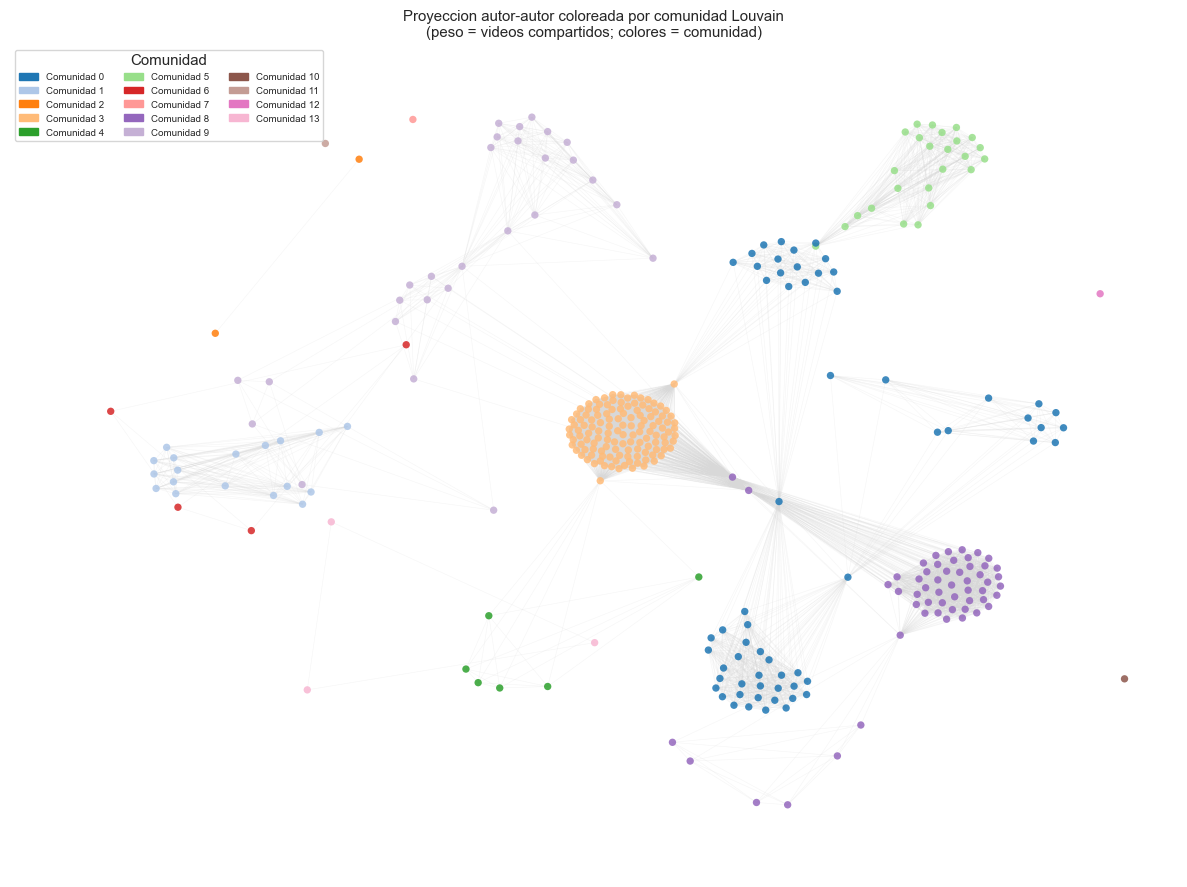

In [82]:
# Visualizacion de comunidades en la proyeccion autor-autor
fig, ax = plt.subplots(figsize=(12, 9))
pos_aa = nx.spring_layout(proj_autor_autor, seed=3066, k=0.35)

nx.draw_networkx_edges(proj_autor_autor, pos_aa, width=0.4, edge_color="#D8D8D8", alpha=0.25, ax=ax)
nodos_aa = list(proj_autor_autor.nodes)
colores_com = [plt.cm.tab20(part_aa.get(n, 0) % 20) for n in nodos_aa]
nx.draw_networkx_nodes(proj_autor_autor, pos_aa, nodelist=nodos_aa, node_color=colores_com,
                       node_size=28, alpha=0.85, linewidths=0, ax=ax)

import matplotlib.patches as mpatches
leyendas = [mpatches.Patch(color=plt.cm.tab20(k % 20), label=f"Comunidad {k}")
            for k in sorted(set(part_aa.values()))]
ax.legend(handles=leyendas, title="Comunidad", fontsize=7, ncol=3, loc="upper left")
ax.set_title("Proyeccion autor-autor coloreada por comunidad Louvain\n(peso = videos compartidos; colores = comunidad)")
ax.axis("off")
plt.tight_layout()
plt.show()

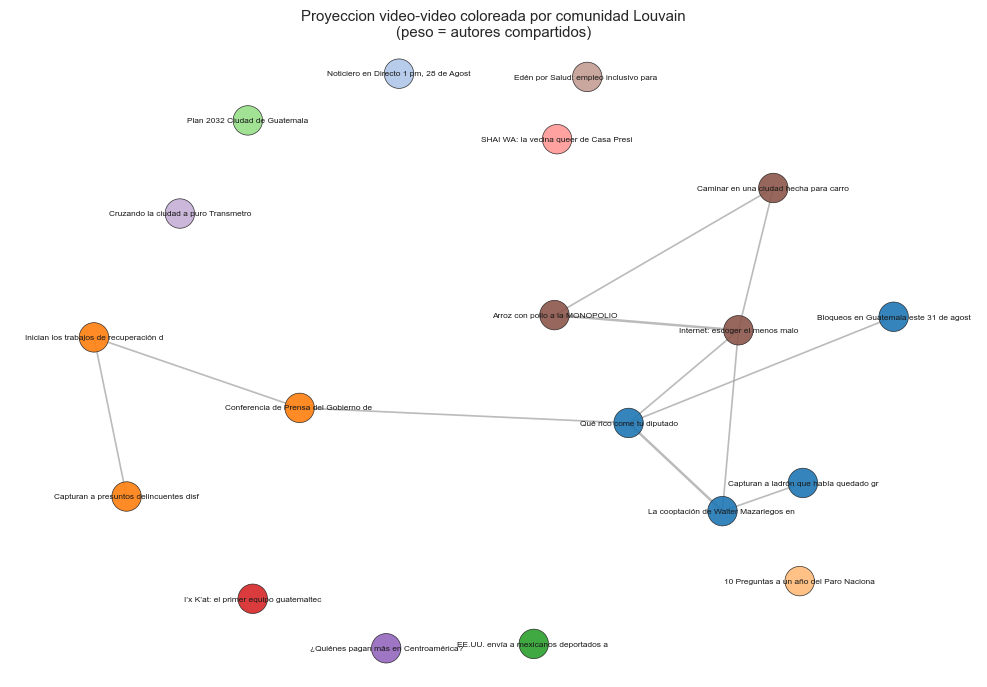

In [83]:
# Visualizacion de comunidades en la proyeccion video-video
fig, ax = plt.subplots(figsize=(10, 7))
pos_vv = nx.spring_layout(proj_video_video, seed=3066, k=1.2)

pesos_vv_vis = nx.get_edge_attributes(proj_video_video, "weight")
nx.draw_networkx_edges(proj_video_video, pos_vv,
                       width=[0.6 + 0.6 * w for w in pesos_vv_vis.values()],
                       edge_color="#9E9E9E", alpha=0.7, ax=ax)
nodos_vv = list(proj_video_video.nodes)
colores_vv = [plt.cm.tab20(part_vv.get(n, 0) % 20) for n in nodos_vv]
nx.draw_networkx_nodes(proj_video_video, pos_vv, nodelist=nodos_vv, node_color=colores_vv,
                       node_size=450, alpha=0.9, edgecolors="#1D1D1D", linewidths=0.5, ax=ax)
labels_vv = {n: str(titulo_video.get(n, n))[:38] for n in nodos_vv}
nx.draw_networkx_labels(proj_video_video, pos_vv, labels_vv, font_size=6, ax=ax)
ax.set_title("Proyeccion video-video coloreada por comunidad Louvain\n(peso = autores compartidos)")
ax.axis("off")
plt.tight_layout()
plt.show()

### Interpretación de los resultados

- **Louvain sobre autor-autor:** encontró **14 comunidades** con modularidad ponderada **0.395** (agrupamiento estructural moderado). Dos comunidades concentran a la mayoría de los usuarios: la **comunidad 3 (126 autores)** asociada a *"Qué rico come tu diputado"* —el video-hub de grado 128— y la **comunidad 0 (61 autores)** asociada a *"Inician los trabajos de recuperación del Puente Belice II"* y *"Conferencia de Prensa del Gobierno de Guatemala"*. Otras comunidades se anclan en videos específicos: la **comunidad 8 (55 autores)** en *"La cooptación de Walter Mazariegos en la USAC"*, la **comunidad 1 (18 autores)** en *"EE.UU. envía a mexicanos deportados a Guatemala"*, la **comunidad 5 (25 autores)** en *"Plan 2032 Ciudad de Guatemala"* y la **comunidad 11 (28 autores)** en el cluster de *"Arroz con pollo a la MONOPOLIO / Internet: escoger el menos malo"*.

- **Lectura sustantiva:** las comunidades de la proyección autor-autor se organizan alrededor de **videos concretos**, no de una afinidad estable entre personas. Esto es coherente con la concentración observada (sección 3.2) y con que el 97.3 % de los autores participa en un solo video: cada comunidad es, en gran medida, la *audiencia de un video-hub*. La modularidad de 0.395 refleja ese efecto de co-presencia en pocos contenidos, no comunidades sociales consolidadas.

- **Louvain sobre video-video:** separó los 19 videos en **12 comunidades** (modularidad 0.405), con la mayoría de los videos **aislados como comunidades de un solo nodo** porque comparten poca audiencia. Los únicos grupos multi-video son los pares con 2 autores compartidos (p. ej., *"La cooptación de Walter Mazariegos"* con *"Qué rico come tu diputado"*, y *"Internet: escoger el menos malo"* con *"Arroz con pollo a la MONOPOLIO"*). Esto confirma la **débil separación temática de la muestra por consultas**: los solapamientos de audiencia son escasos y localizados.

- **Contraste con las componentes (sección 6):** las componentes conexas son la respuesta a *"¿está la red rota?"* (10 componentes, una gigante). Las comunidades de Louvain responden a *"¿dónde está la estructura de subgrupos densos?"*. Sobre la proyección autor-autor, Louvain *refina* la componente gigante en subgrupos centrados en videos-hub, mostrando que la conectividad estructural no implica cohesión de comunidades temáticas diferenciadas.

- **Cuidado interpretativo:** ninguna comunidad implica amistad, conversación ni aprobación entre sus miembros. Las comunidades detectadas reflejan **co-participación en los contenidos recolectados** y heredan los sesgos de cobertura (274 videos sin comentarios y solapamiento débil).

In [84]:
# Exportar resultados de comunidades
autores_com[["node_id", "id_original", "etiqueta", "comunidad_aa"]].to_csv(
    "resultados/tablas/comunidades_autores_aa.csv", index=False, encoding="utf-8-sig")
resumen_com.to_csv("resultados/tablas/comunidades_resumen_aa.csv", index=False, encoding="utf-8-sig")
terminos_com.to_csv("resultados/tablas/comunidades_terminos.csv", index=False, encoding="utf-8-sig")
print("RUTA DEL CUADERNO COMPLETADA (secciones 1 a 7).")
print(f"Comunidades Louvain en autor-autor: {len(sizes)} con modularidad {mod_aa:.3f}.")
print(f"Comunidades Louvain en video-video: {len(sizes_vv)} con modularidad {mod_vv:.3f}.")

RUTA DEL CUADERNO COMPLETADA (secciones 1 a 7).
Comunidades Louvain en autor-autor: 14 con modularidad 0.395.
Comunidades Louvain en video-video: 12 con modularidad 0.405.
